In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from pathlib import Path

# 1. Configuration des chemins (Chemin absolu de la racine)
root_path = os.path.abspath('.')
src_path = os.path.join(root_path, 'src')

# Ajout au système de recherche de Python
if root_path not in sys.path:
    sys.path.insert(0, root_path)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 2. Résolution du conflit de nom pour le dossier 'config'
import config.config as cfg
sys.modules['config'] = cfg

# 3. Imports directs (sans filet, car tout est aligné)
from config.config import add_to_path, root_dir, google_folder_id, download_dir
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data



In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=os.path.join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

In [15]:
import random

def create_session_clean(data_dict, session_anomaly):
    """
    Create a list of clean session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of clean session path
    session_clean = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] not in session_anomaly:
            session_clean.append(s)
    
    return session_clean


def split_session(session_clean, p=2/3, seed = None):
    """
    split the list of clean session path into train and test
    """
    if seed is not None:
        random.seed(seed)
    sessions = session_clean.copy()
    random.shuffle(sessions)
    n_train = int(len(sessions) * p)
    session_train = sessions[:n_train]
    session_test = sessions[n_train:]
    return session_train, session_test

def merge_dataset(data_dict, session):
    """ 
    Preprocess the session in the list session and concatenate to a single dataset
    """
    temp_list = []
    for s in session:
        df = data_dict[s].copy()
        df = preprocessing.clean_dataframe(df)
        df['session_id'] = os.path.splitext(os.path.basename(s))[0]
        temp_list.append(df)

    df_train = pd.concat(temp_list, ignore_index=True)
    return df_train

def create_dataset(data_dict, session_anomaly, split=False, p=2/3, seed=423):
    """
    Create the whole preprocessed dataset and remove the anomalous sessions. 

    data_dict (dict): The dictionnary containing all data
    session_anomaly (list): List of name of anomalous sessions
    split (bool): If True, split the dataset to train and test dataset
    p (int, 0<p<1): Ratio train/test
    seed (int): random seed for the split

    Return : 
    if split is False, return whole dataset and the session path list
    if split is True, return train dataset, test dataset and their session path list

    """
    #Create session clean list
    session_clean = create_session_clean(data_dict, session_anomaly)

    # if split is False, we will prerpocess all data
    session_train = session_clean 
    
    # Create train data session path list and test data session path list
    if split :
        session_train, session_test = split_session(session_clean, p, seed)
    
    # Create train dataset
    df_train = merge_dataset(data_dict, session_train)

    # Create test dataset
    if split:
        df_test = merge_dataset(data_dict, session_test)
        return df_train, df_test, session_train, session_test
        
    return df_train, session_train


In [ ]:
#Creat train dataset and test dataset

df_all, df_all_test, list_train, list_test= create_dataset(data_dict, session_anomaly,split=True, seed=423)

In [ ]:
from anomaly_detection.deep_learning.isolation_forest import AnomalyDetectorIF


# Creation of the datasets (train and test)
df_train, df_test, list_train, list_test = create_dataset(
    data_dict, 
    session_anomaly=session_anomaly, 
    split=True, 
    p=2/3, 
    seed=423
)

#Definte the columns coresponding to a sensor
features = [c for c in df_train.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if = AnomalyDetectorIF(contamination=0.01)
clf_if.fit(df_train, features)

#Test the model on the test dataset
results_clean = clf_if.predict_anomalies(df_test)





# Test on filtered data 

In [40]:
print(f"Number of points notified as abnormal : {results_clean['anomaly_detected'].sum()}")
print(f"Percent : {results_clean['anomaly_detected'].mean() * 100:.2f}%")

Number of points notified as abnormal : 873
Percent : 0.91%


On the test dataset, which contains only nominal (healthy) sessions, the Isolation Forest model detects very few anomalies (0.91%). This confirms a low False Positive Rate, meaning the model does not trigger unnecessary alerts during normal driving

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3358.csv
Detection rate : 1.11%


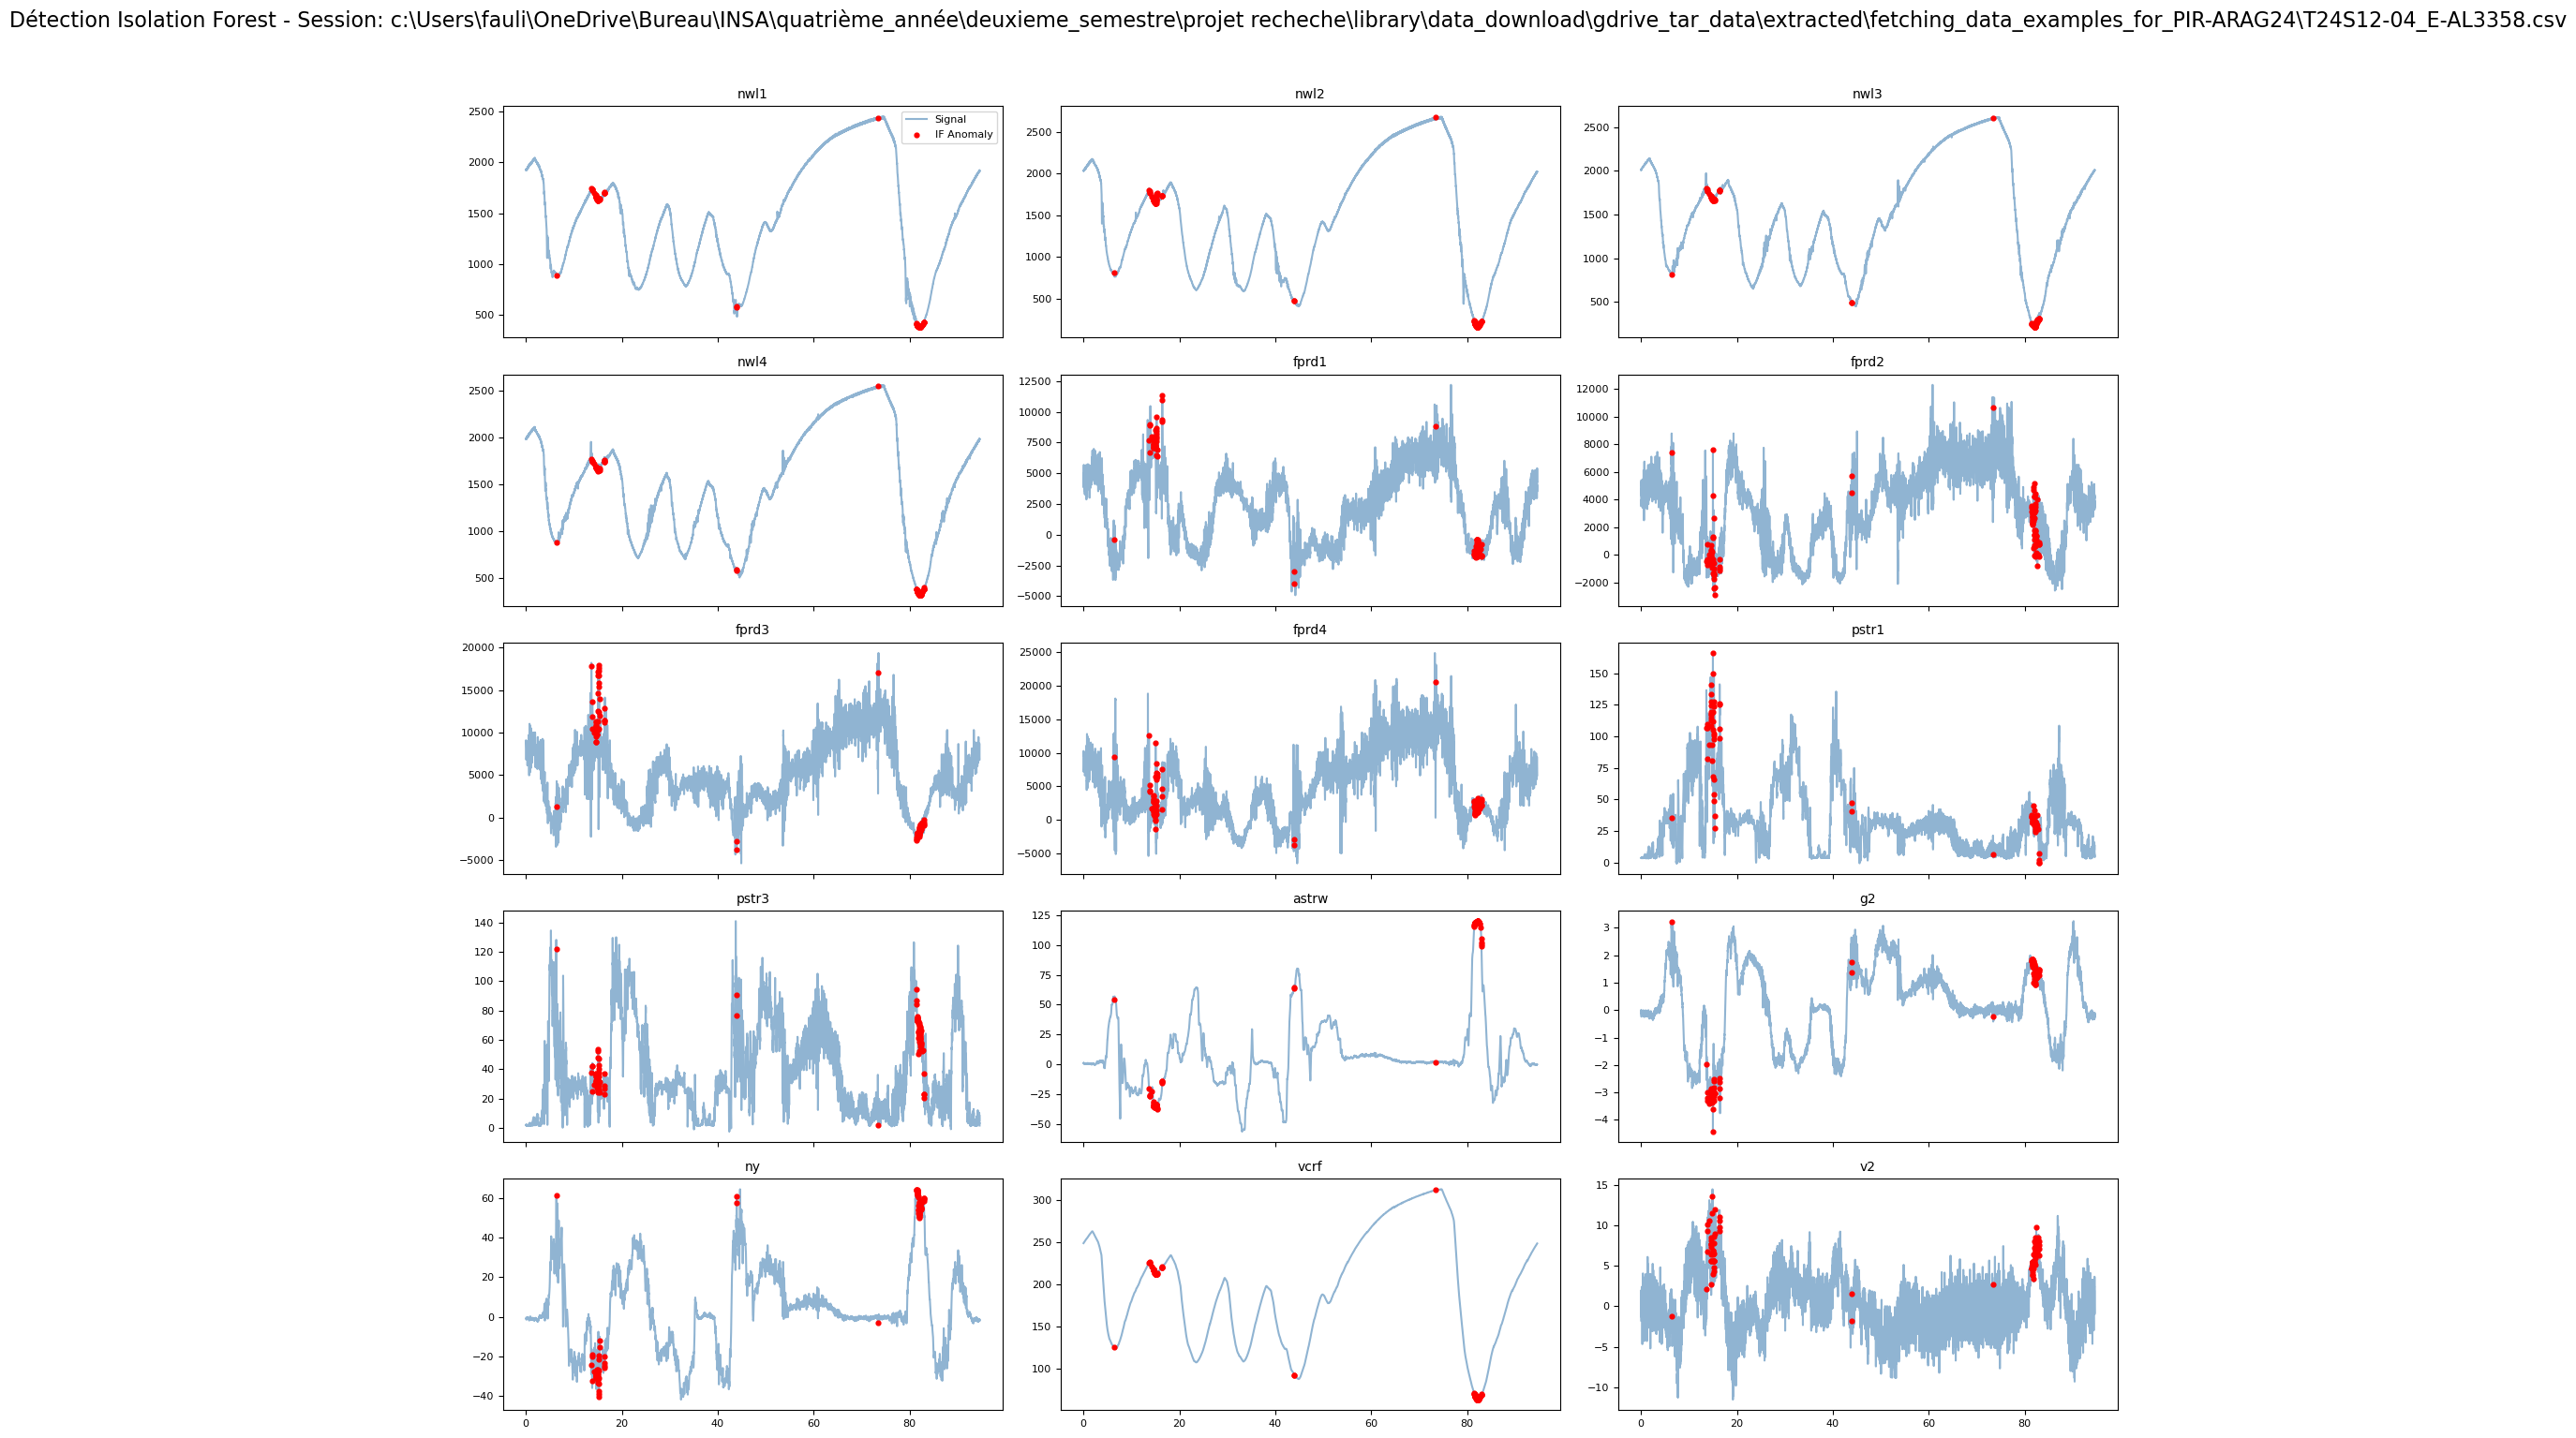

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3397.csv
Detection rate : 1.13%


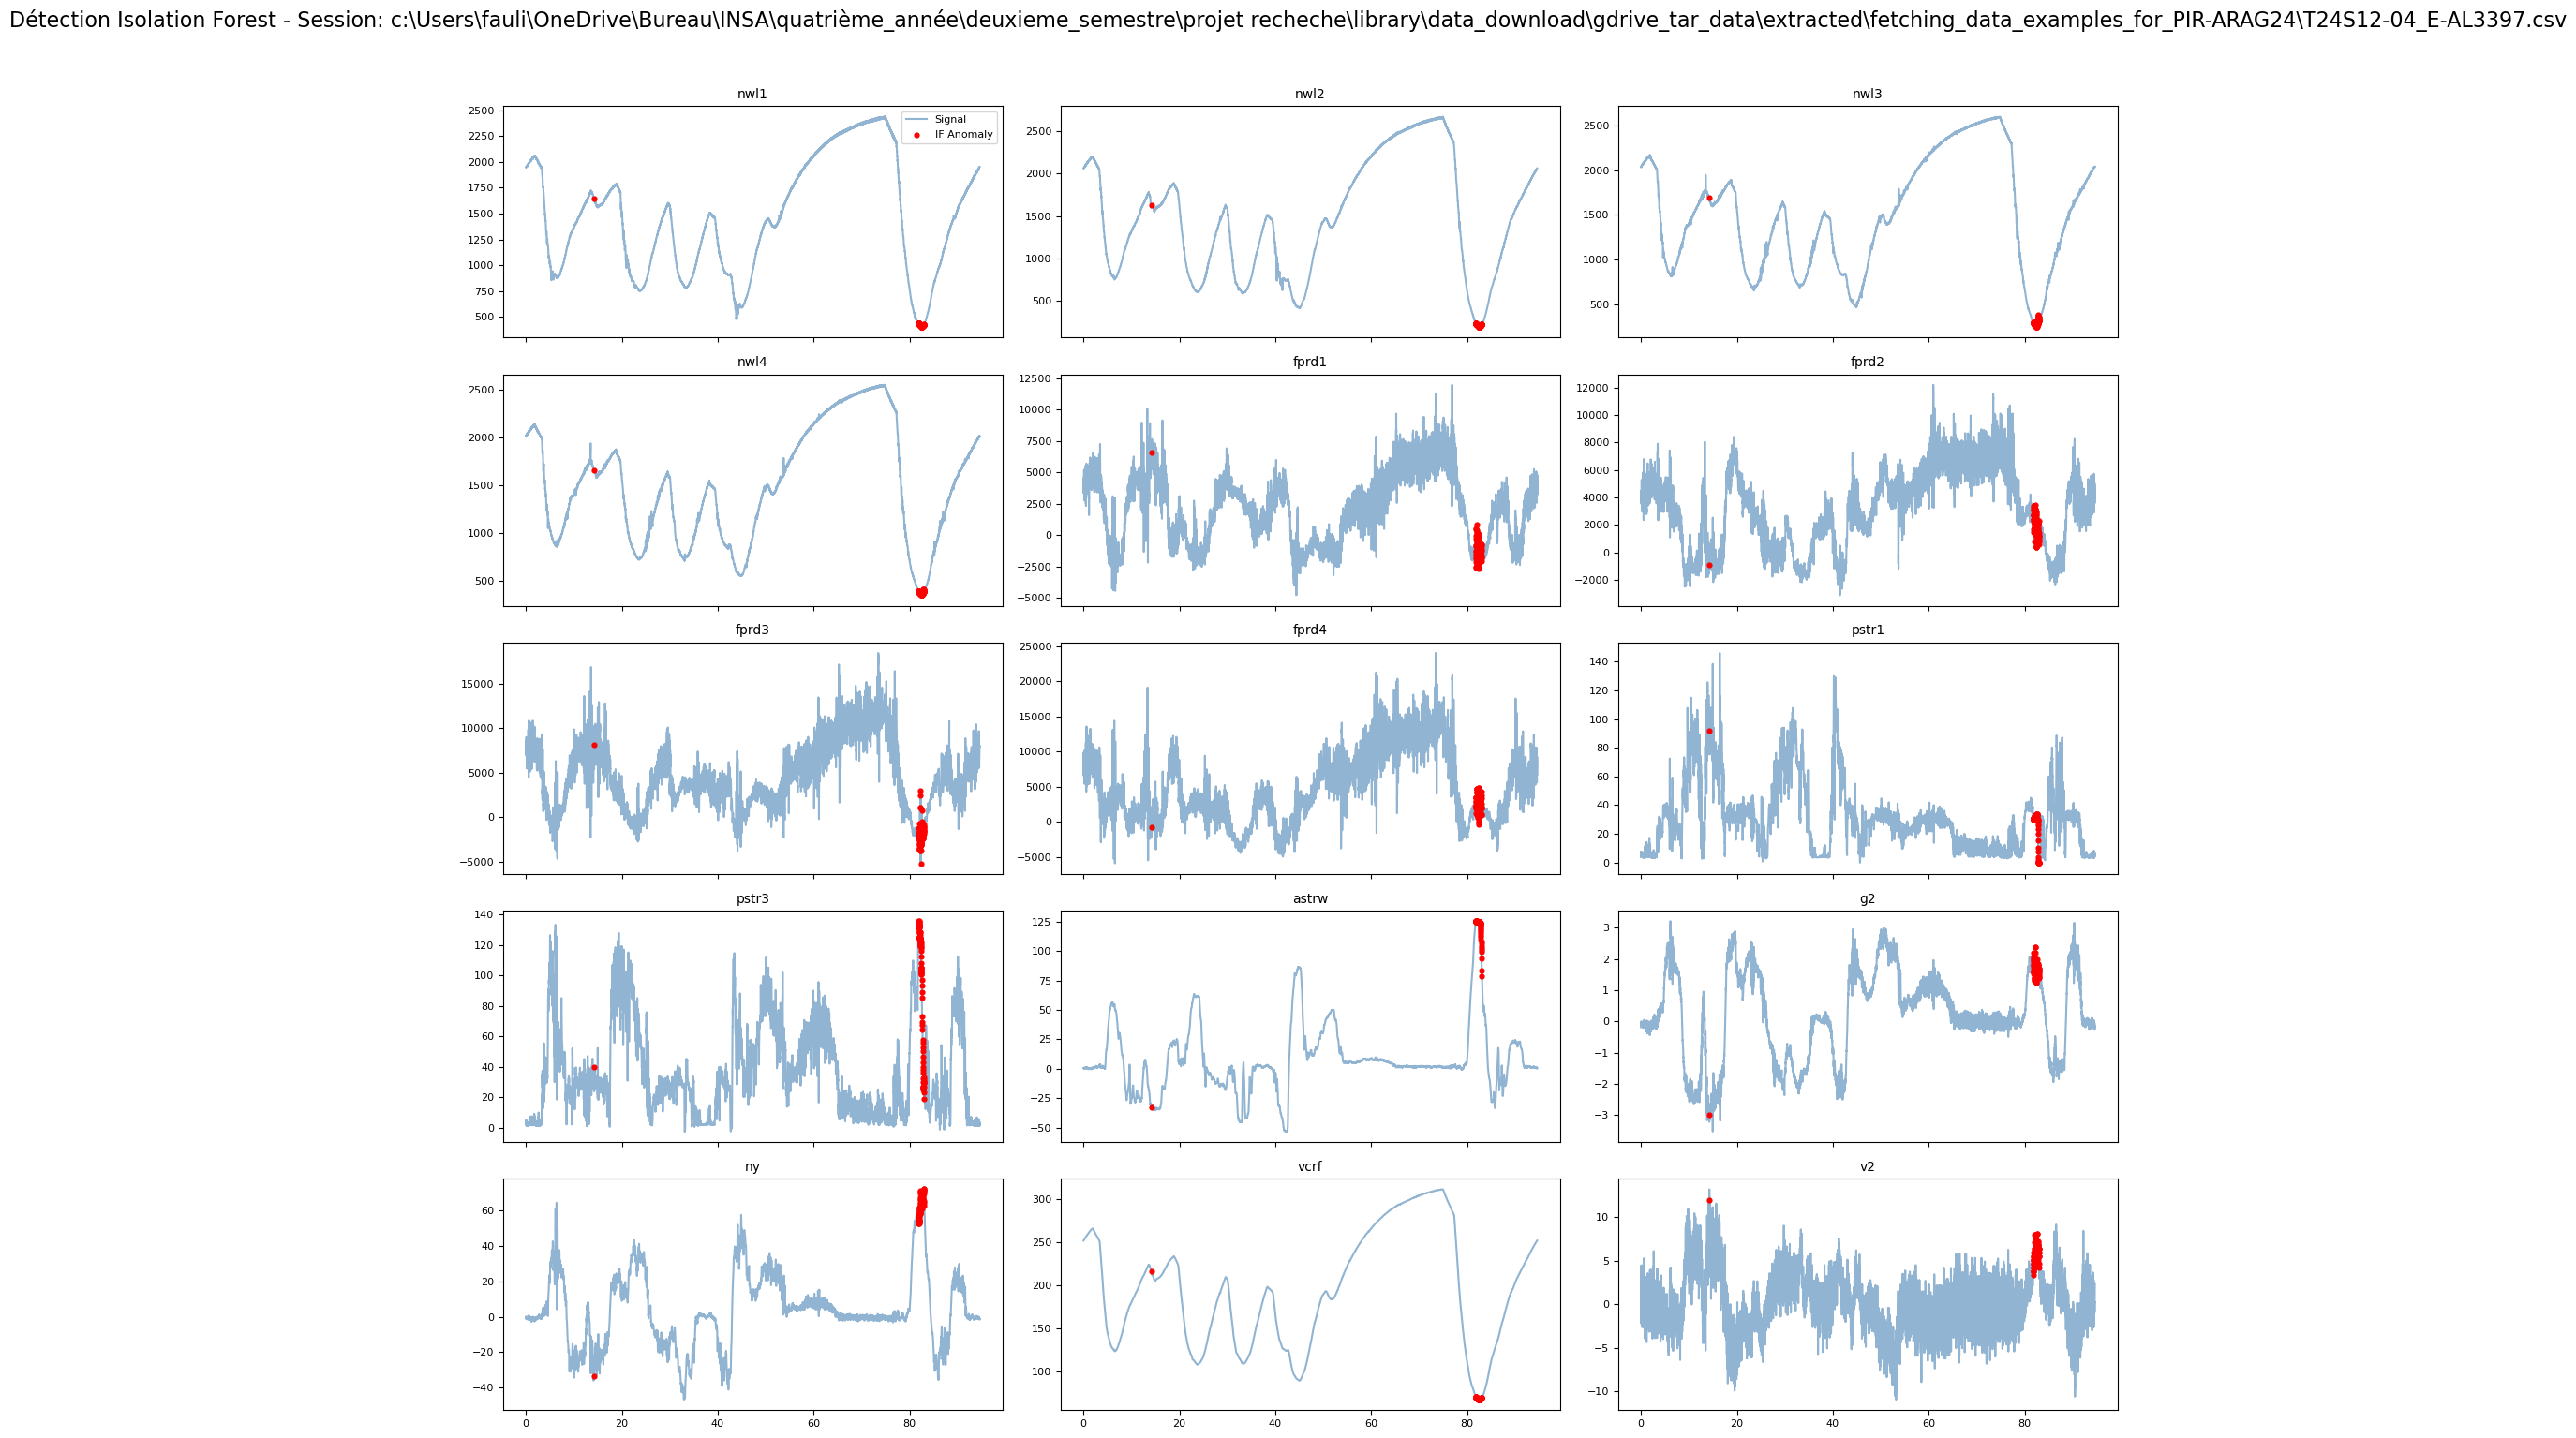

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3479.csv
Detection rate : 0.93%


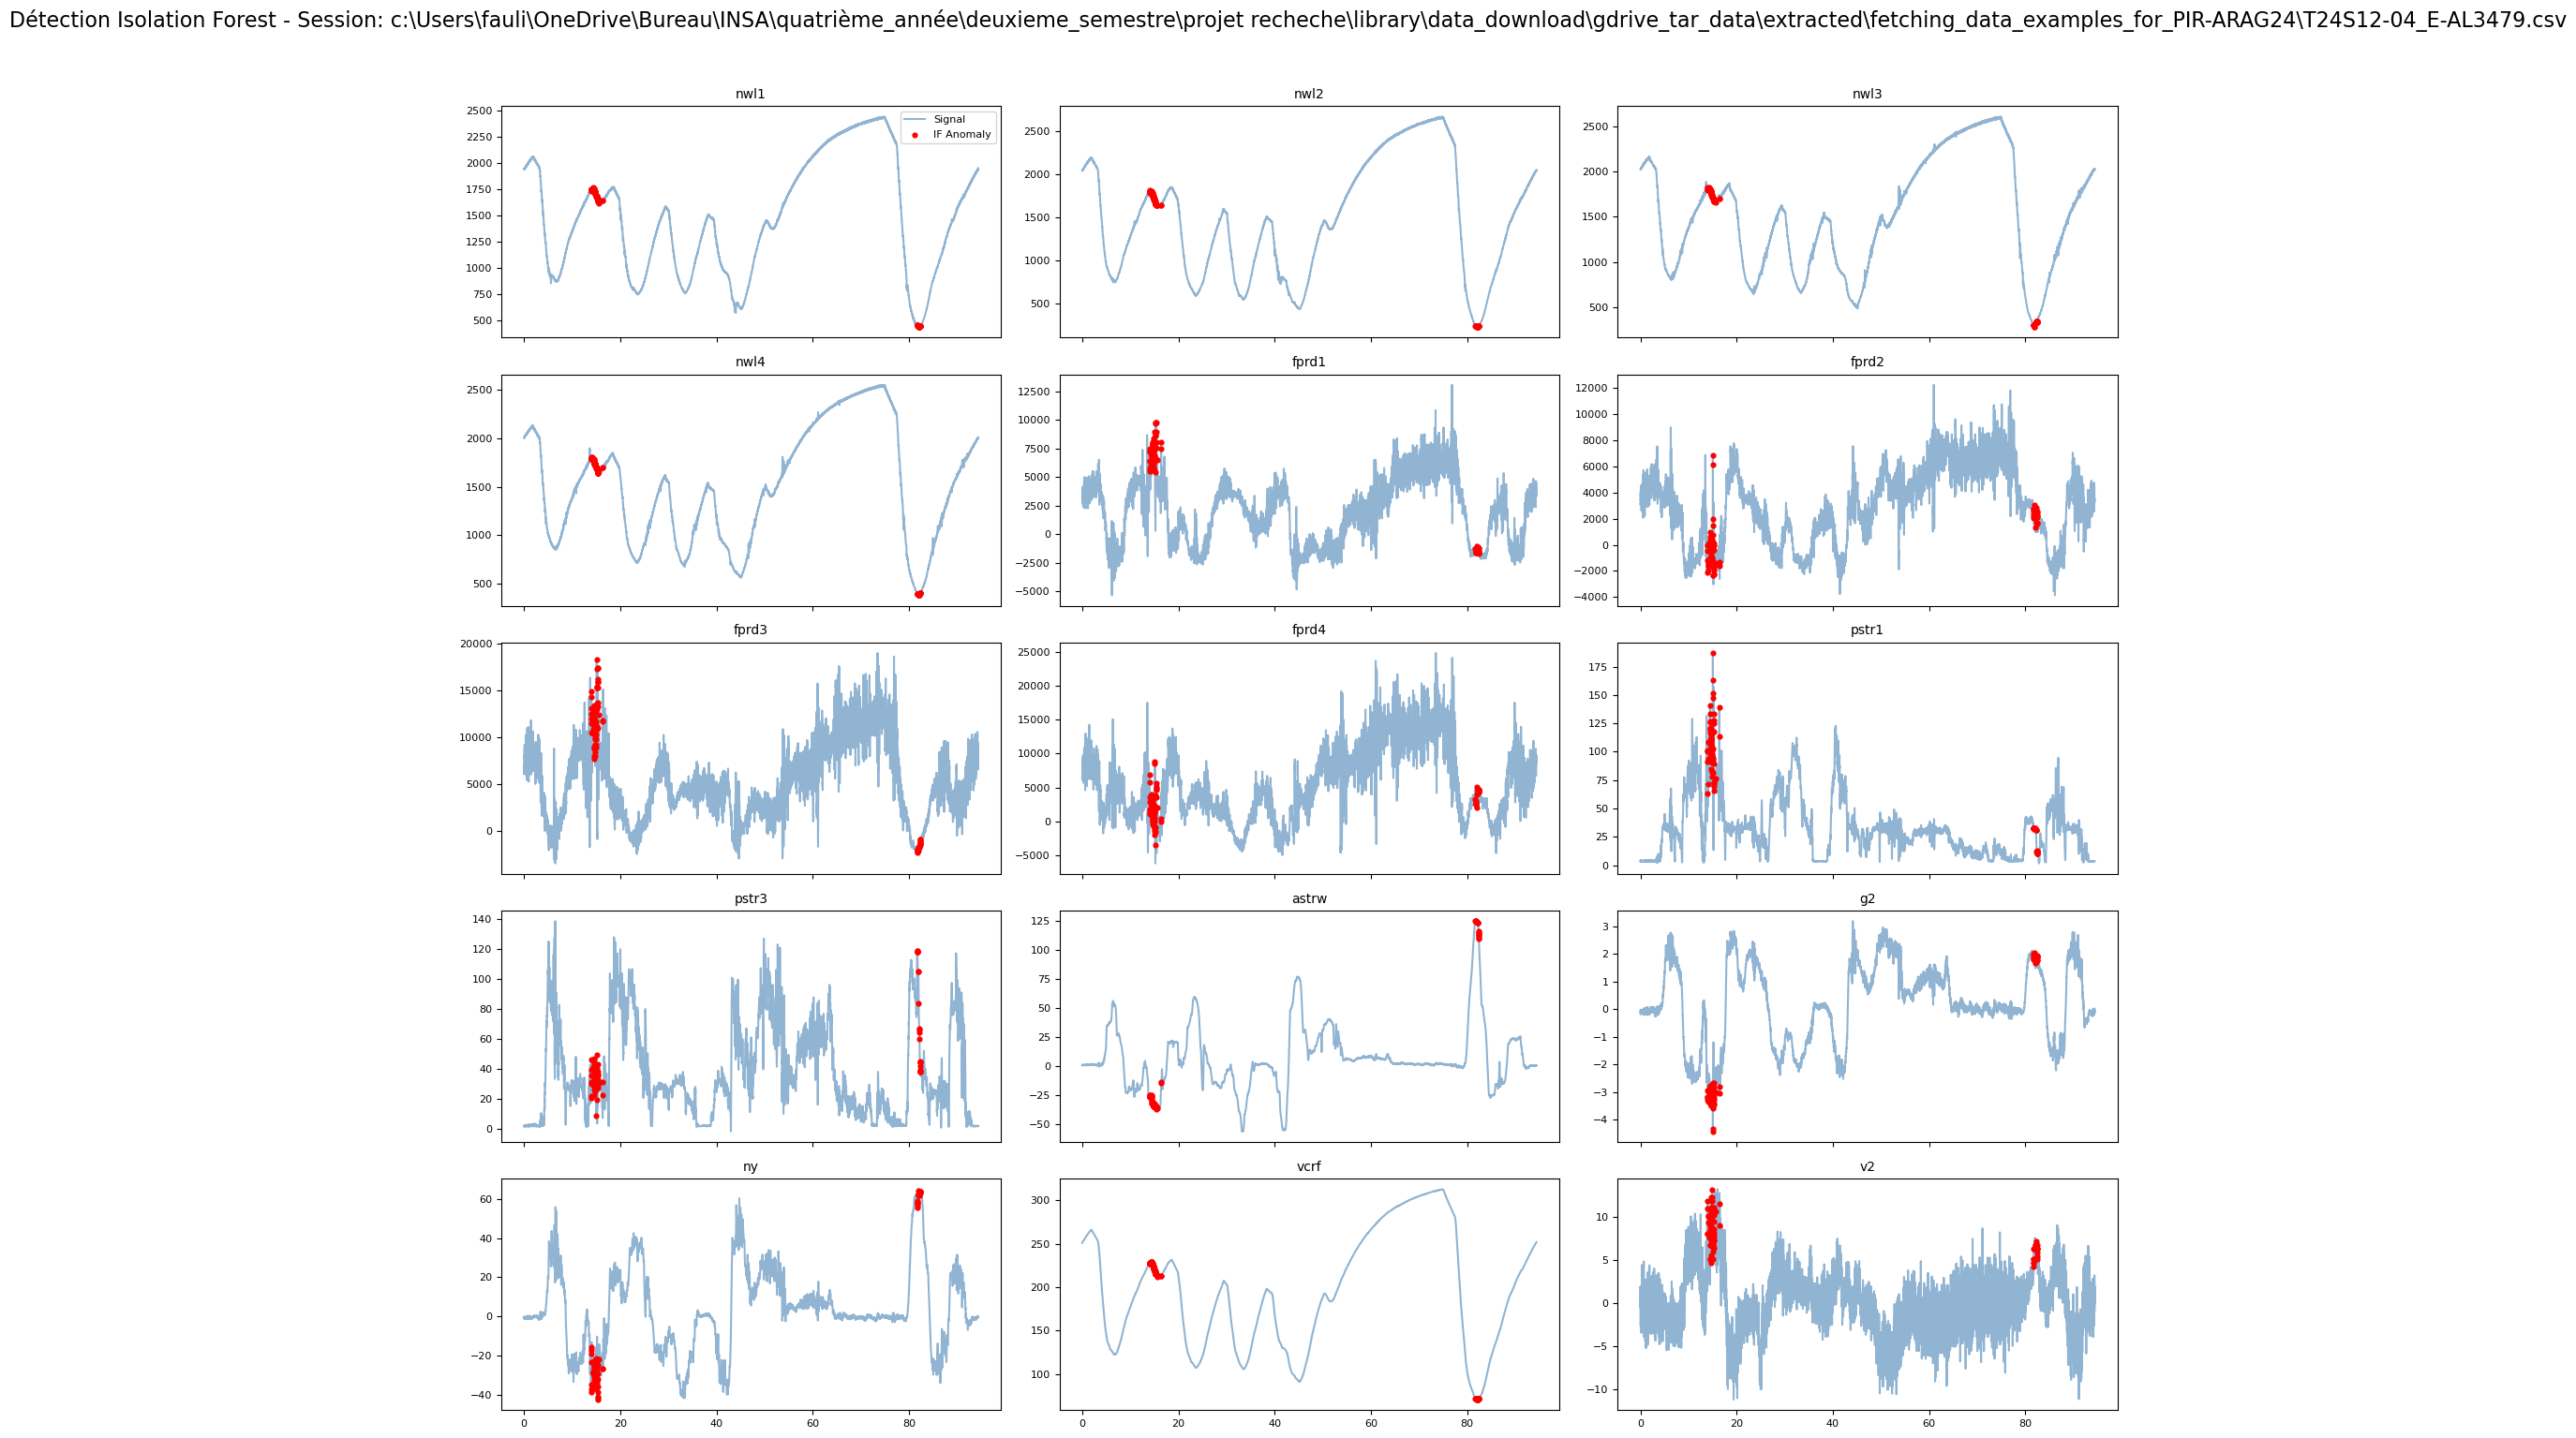

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3499.csv
Detection rate : 0.95%


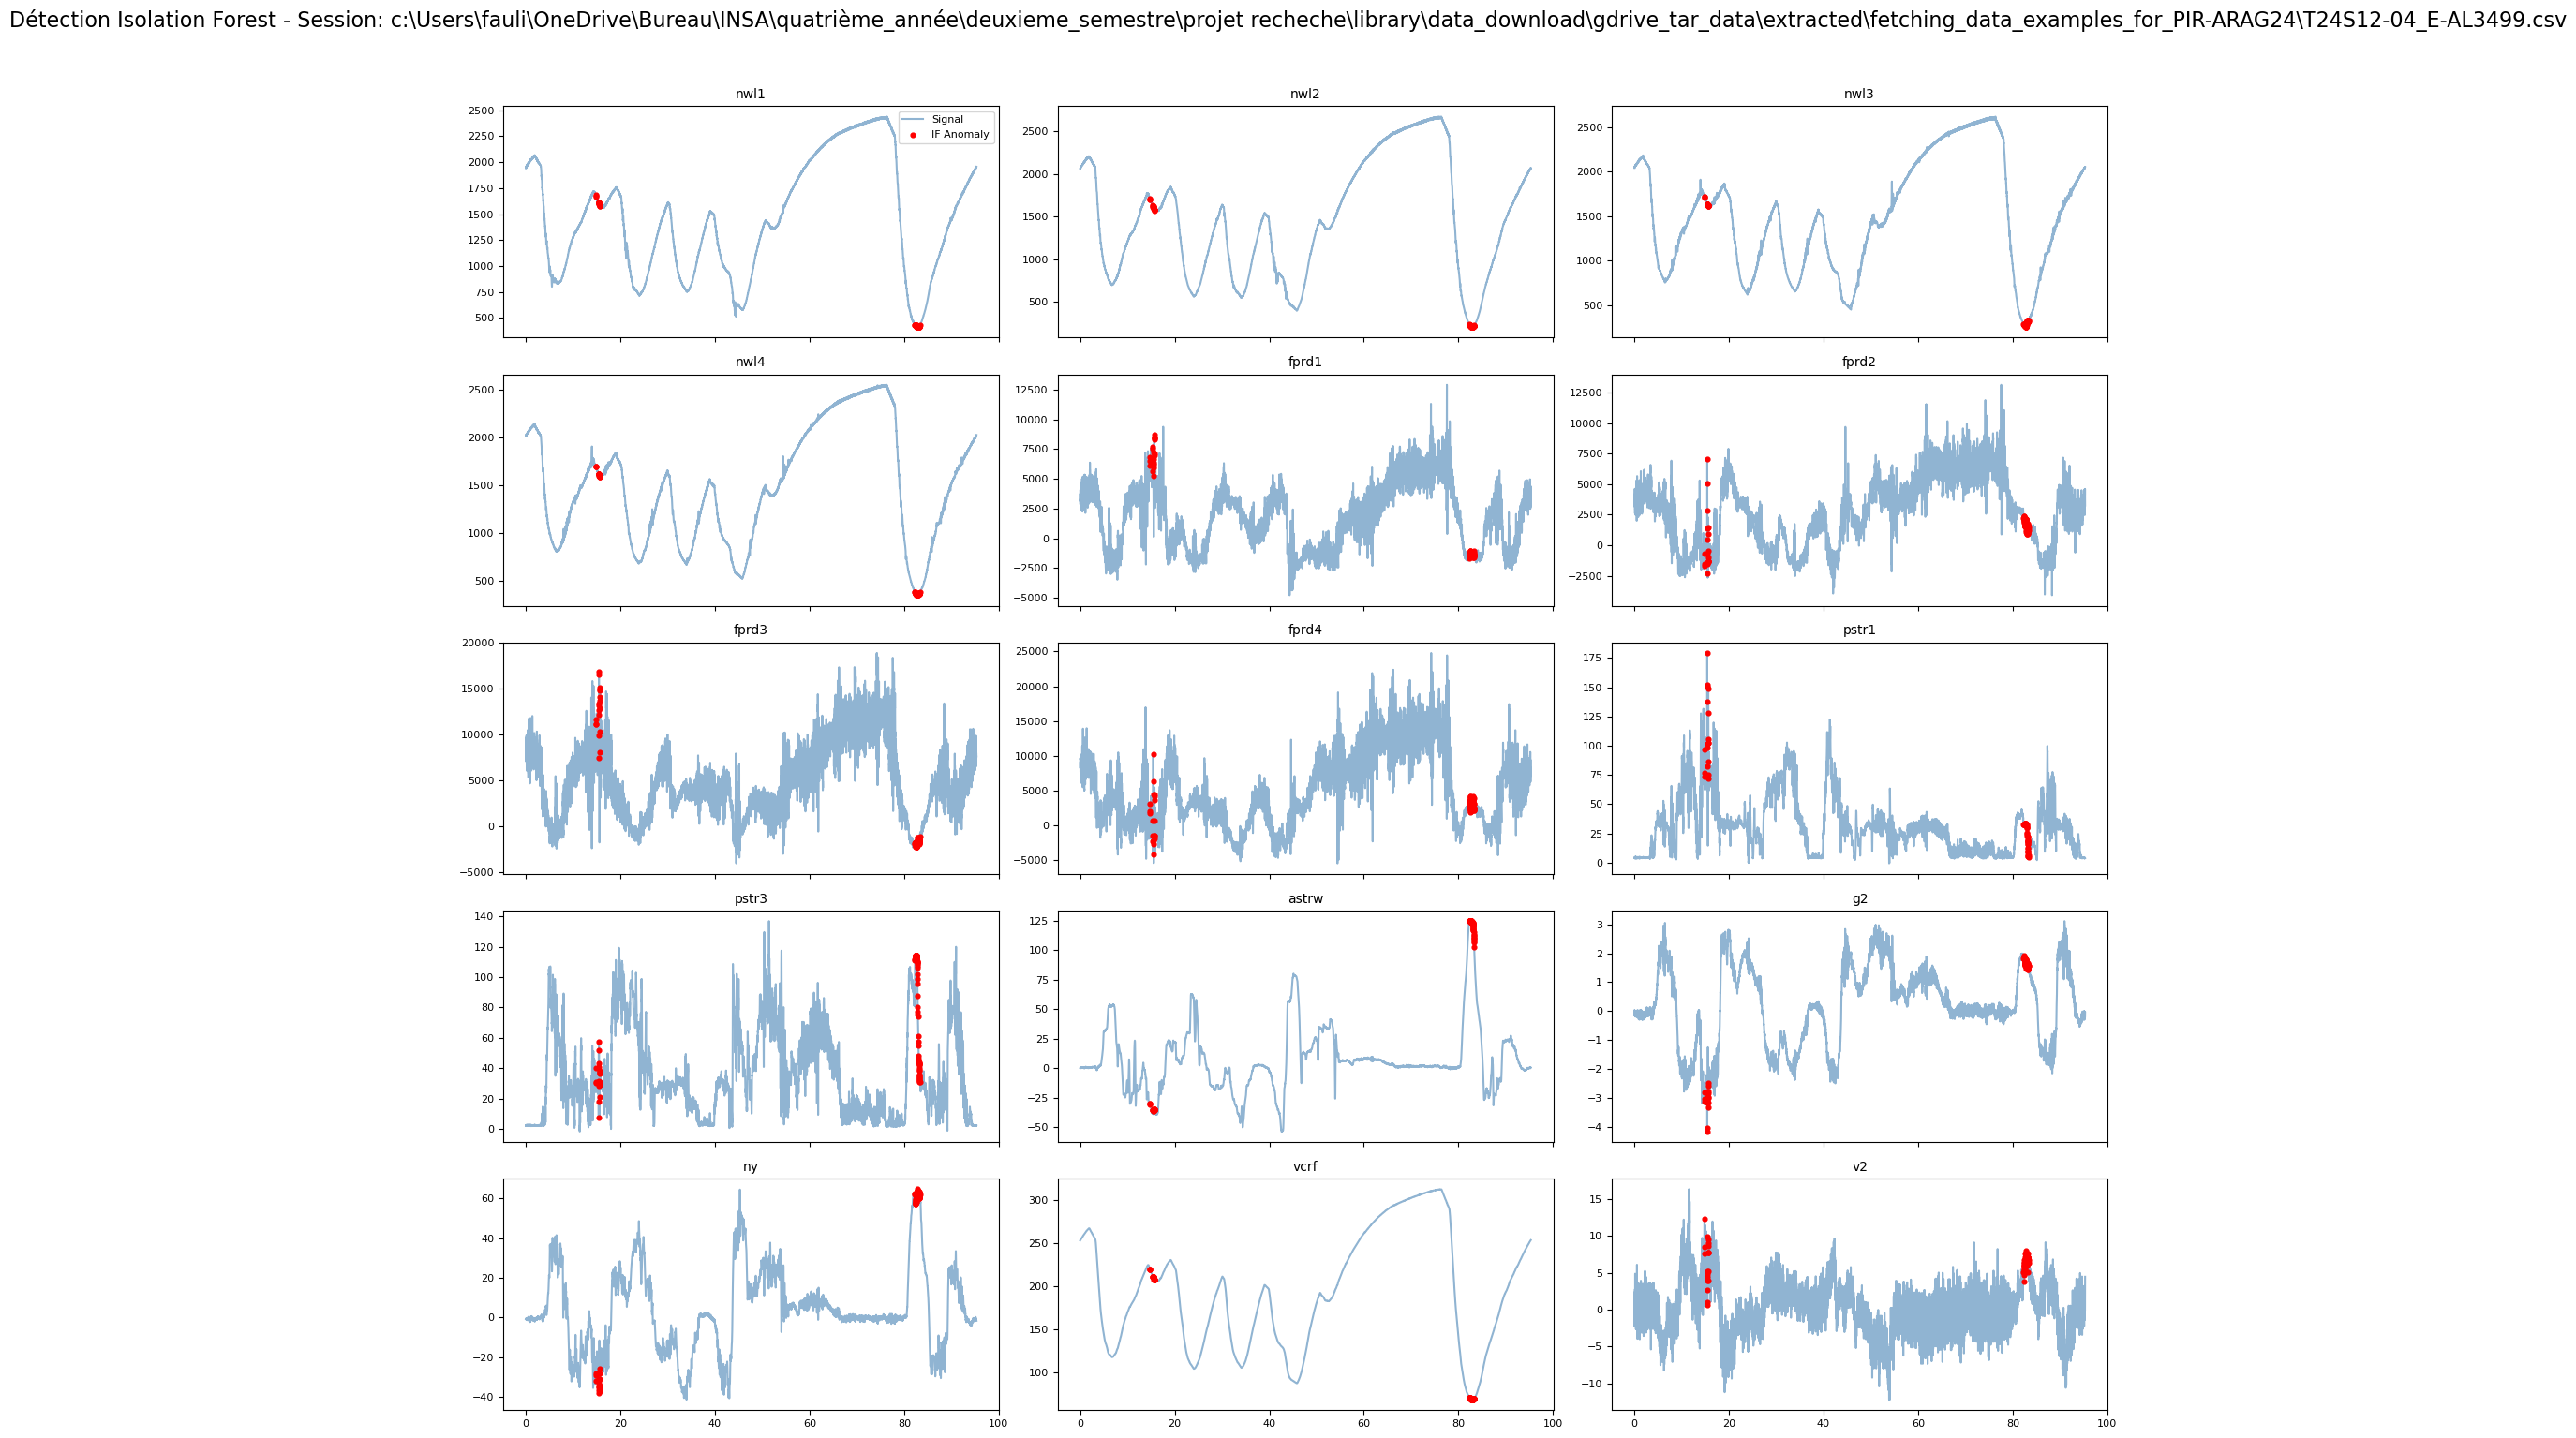

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3558.csv
Detection rate : 1.17%


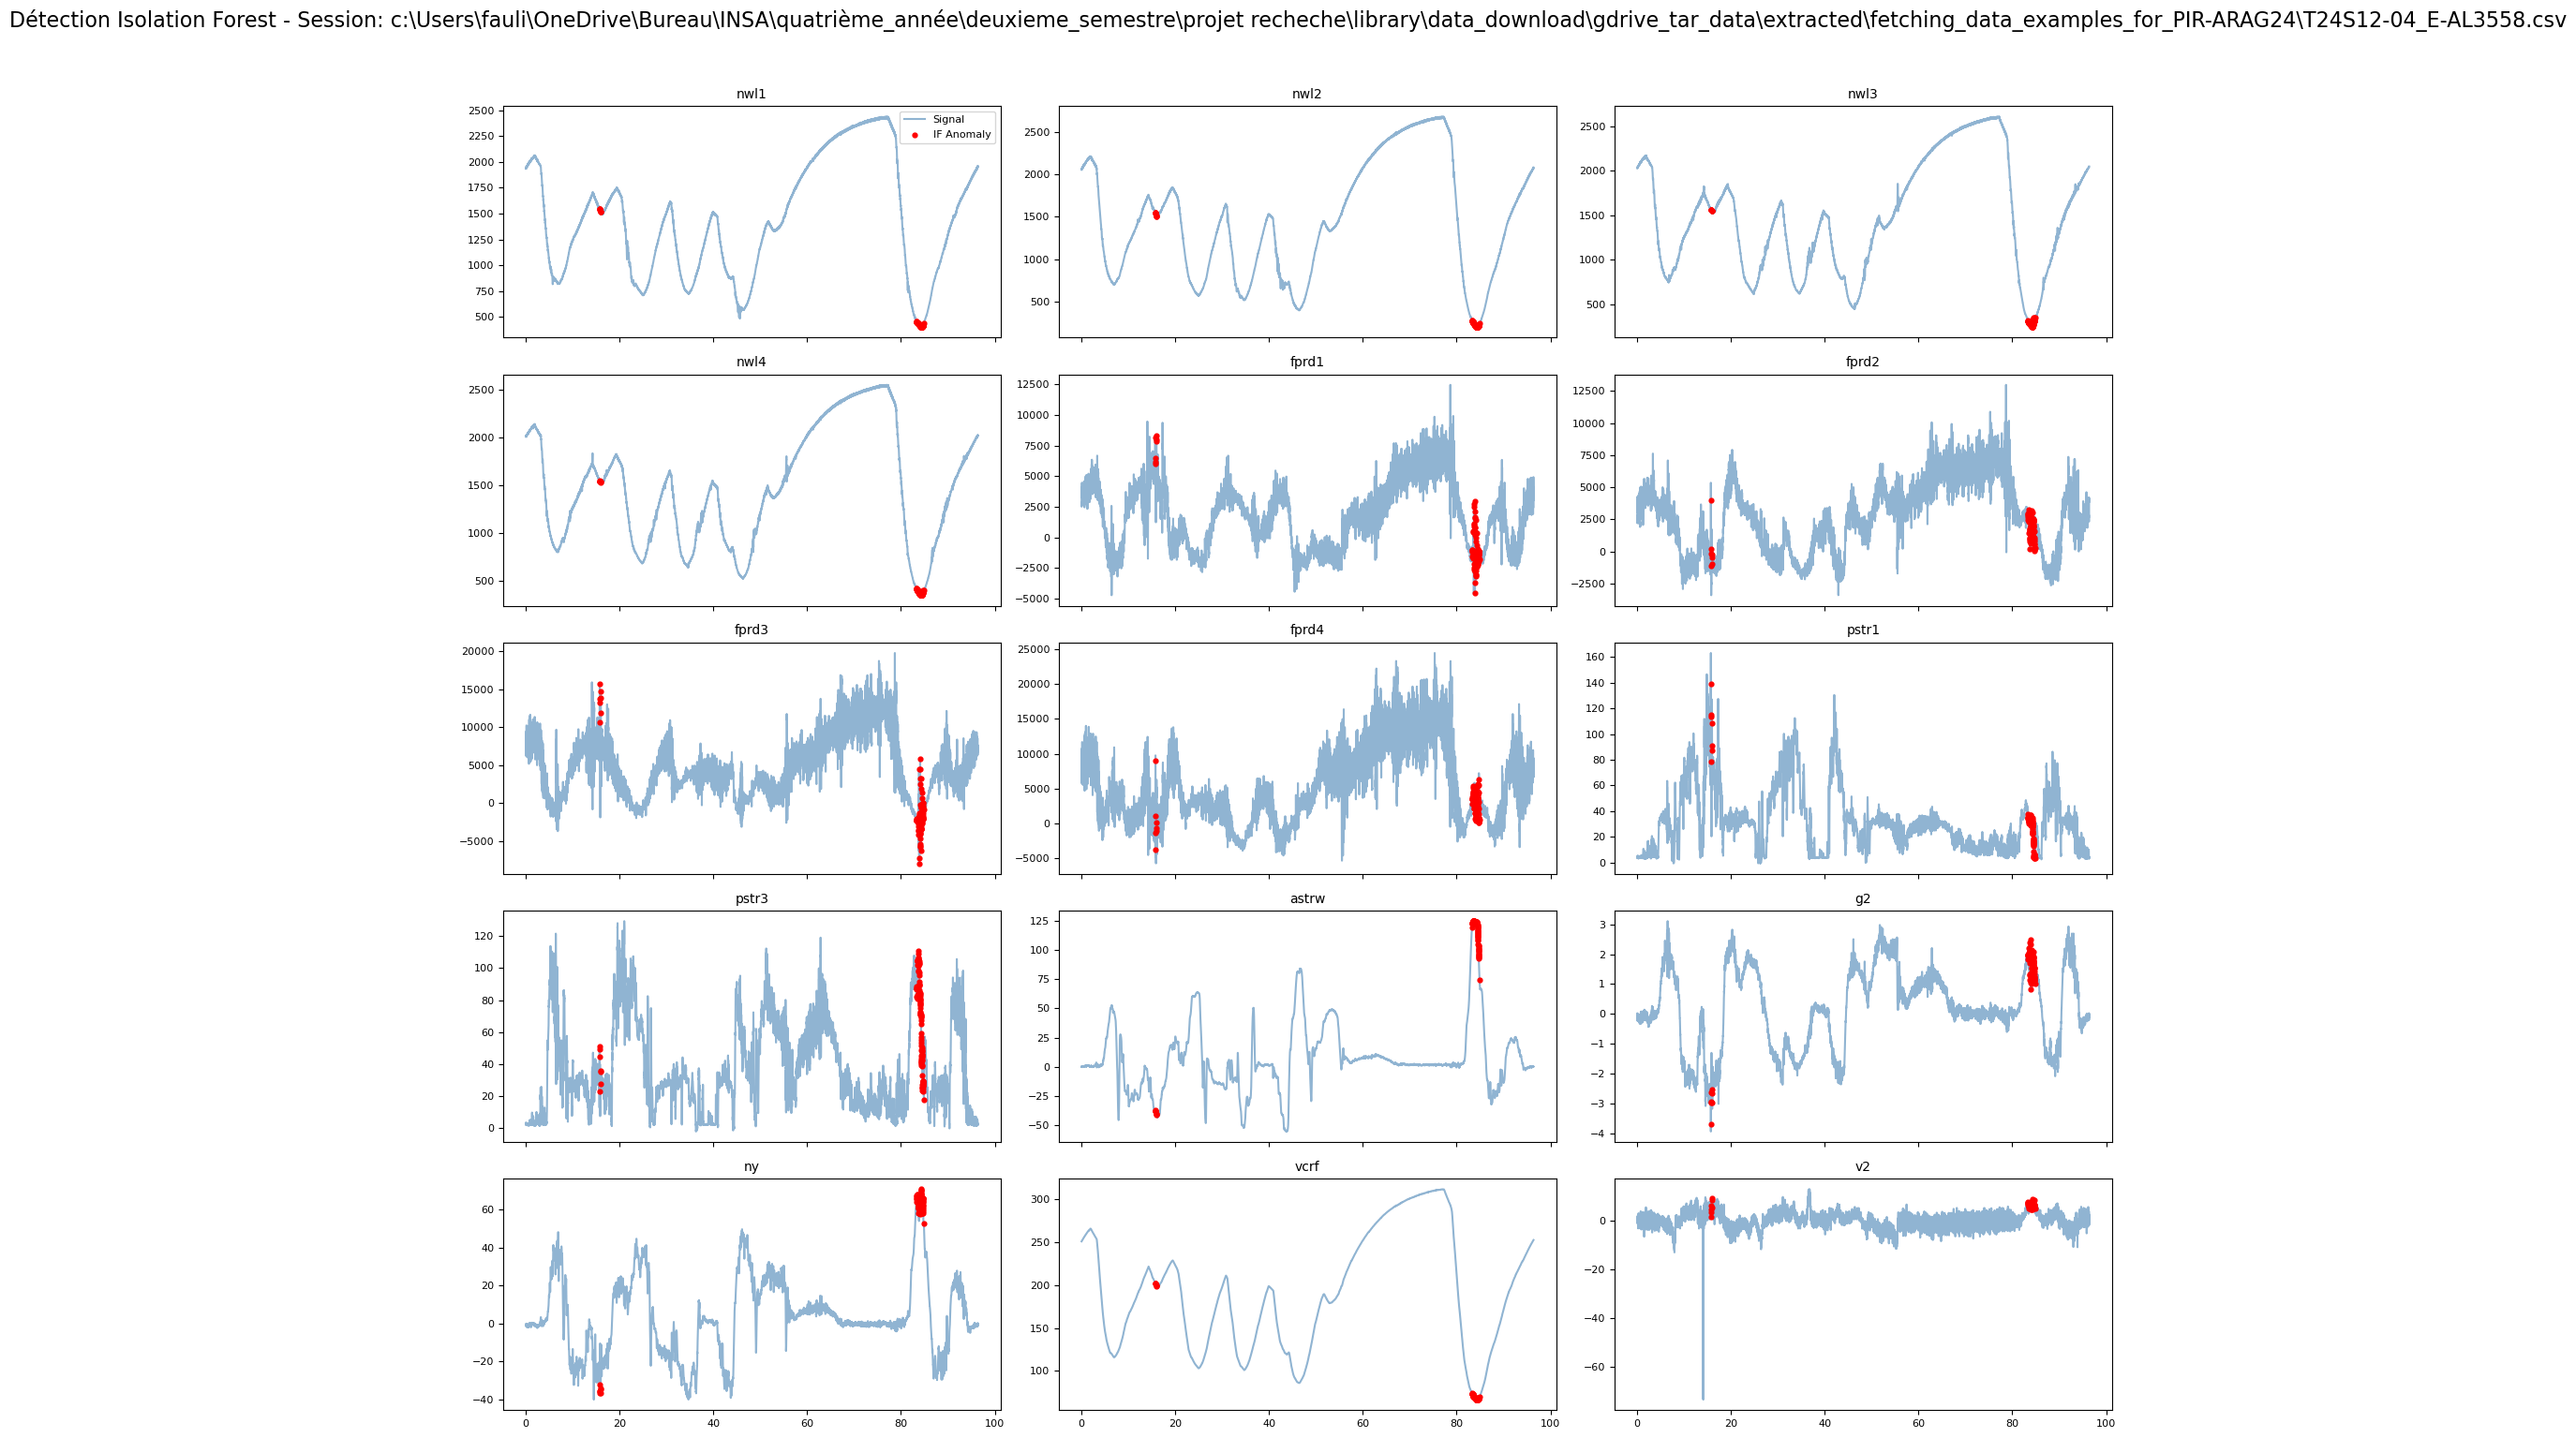

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3538.csv
Detection rate : 0.01%


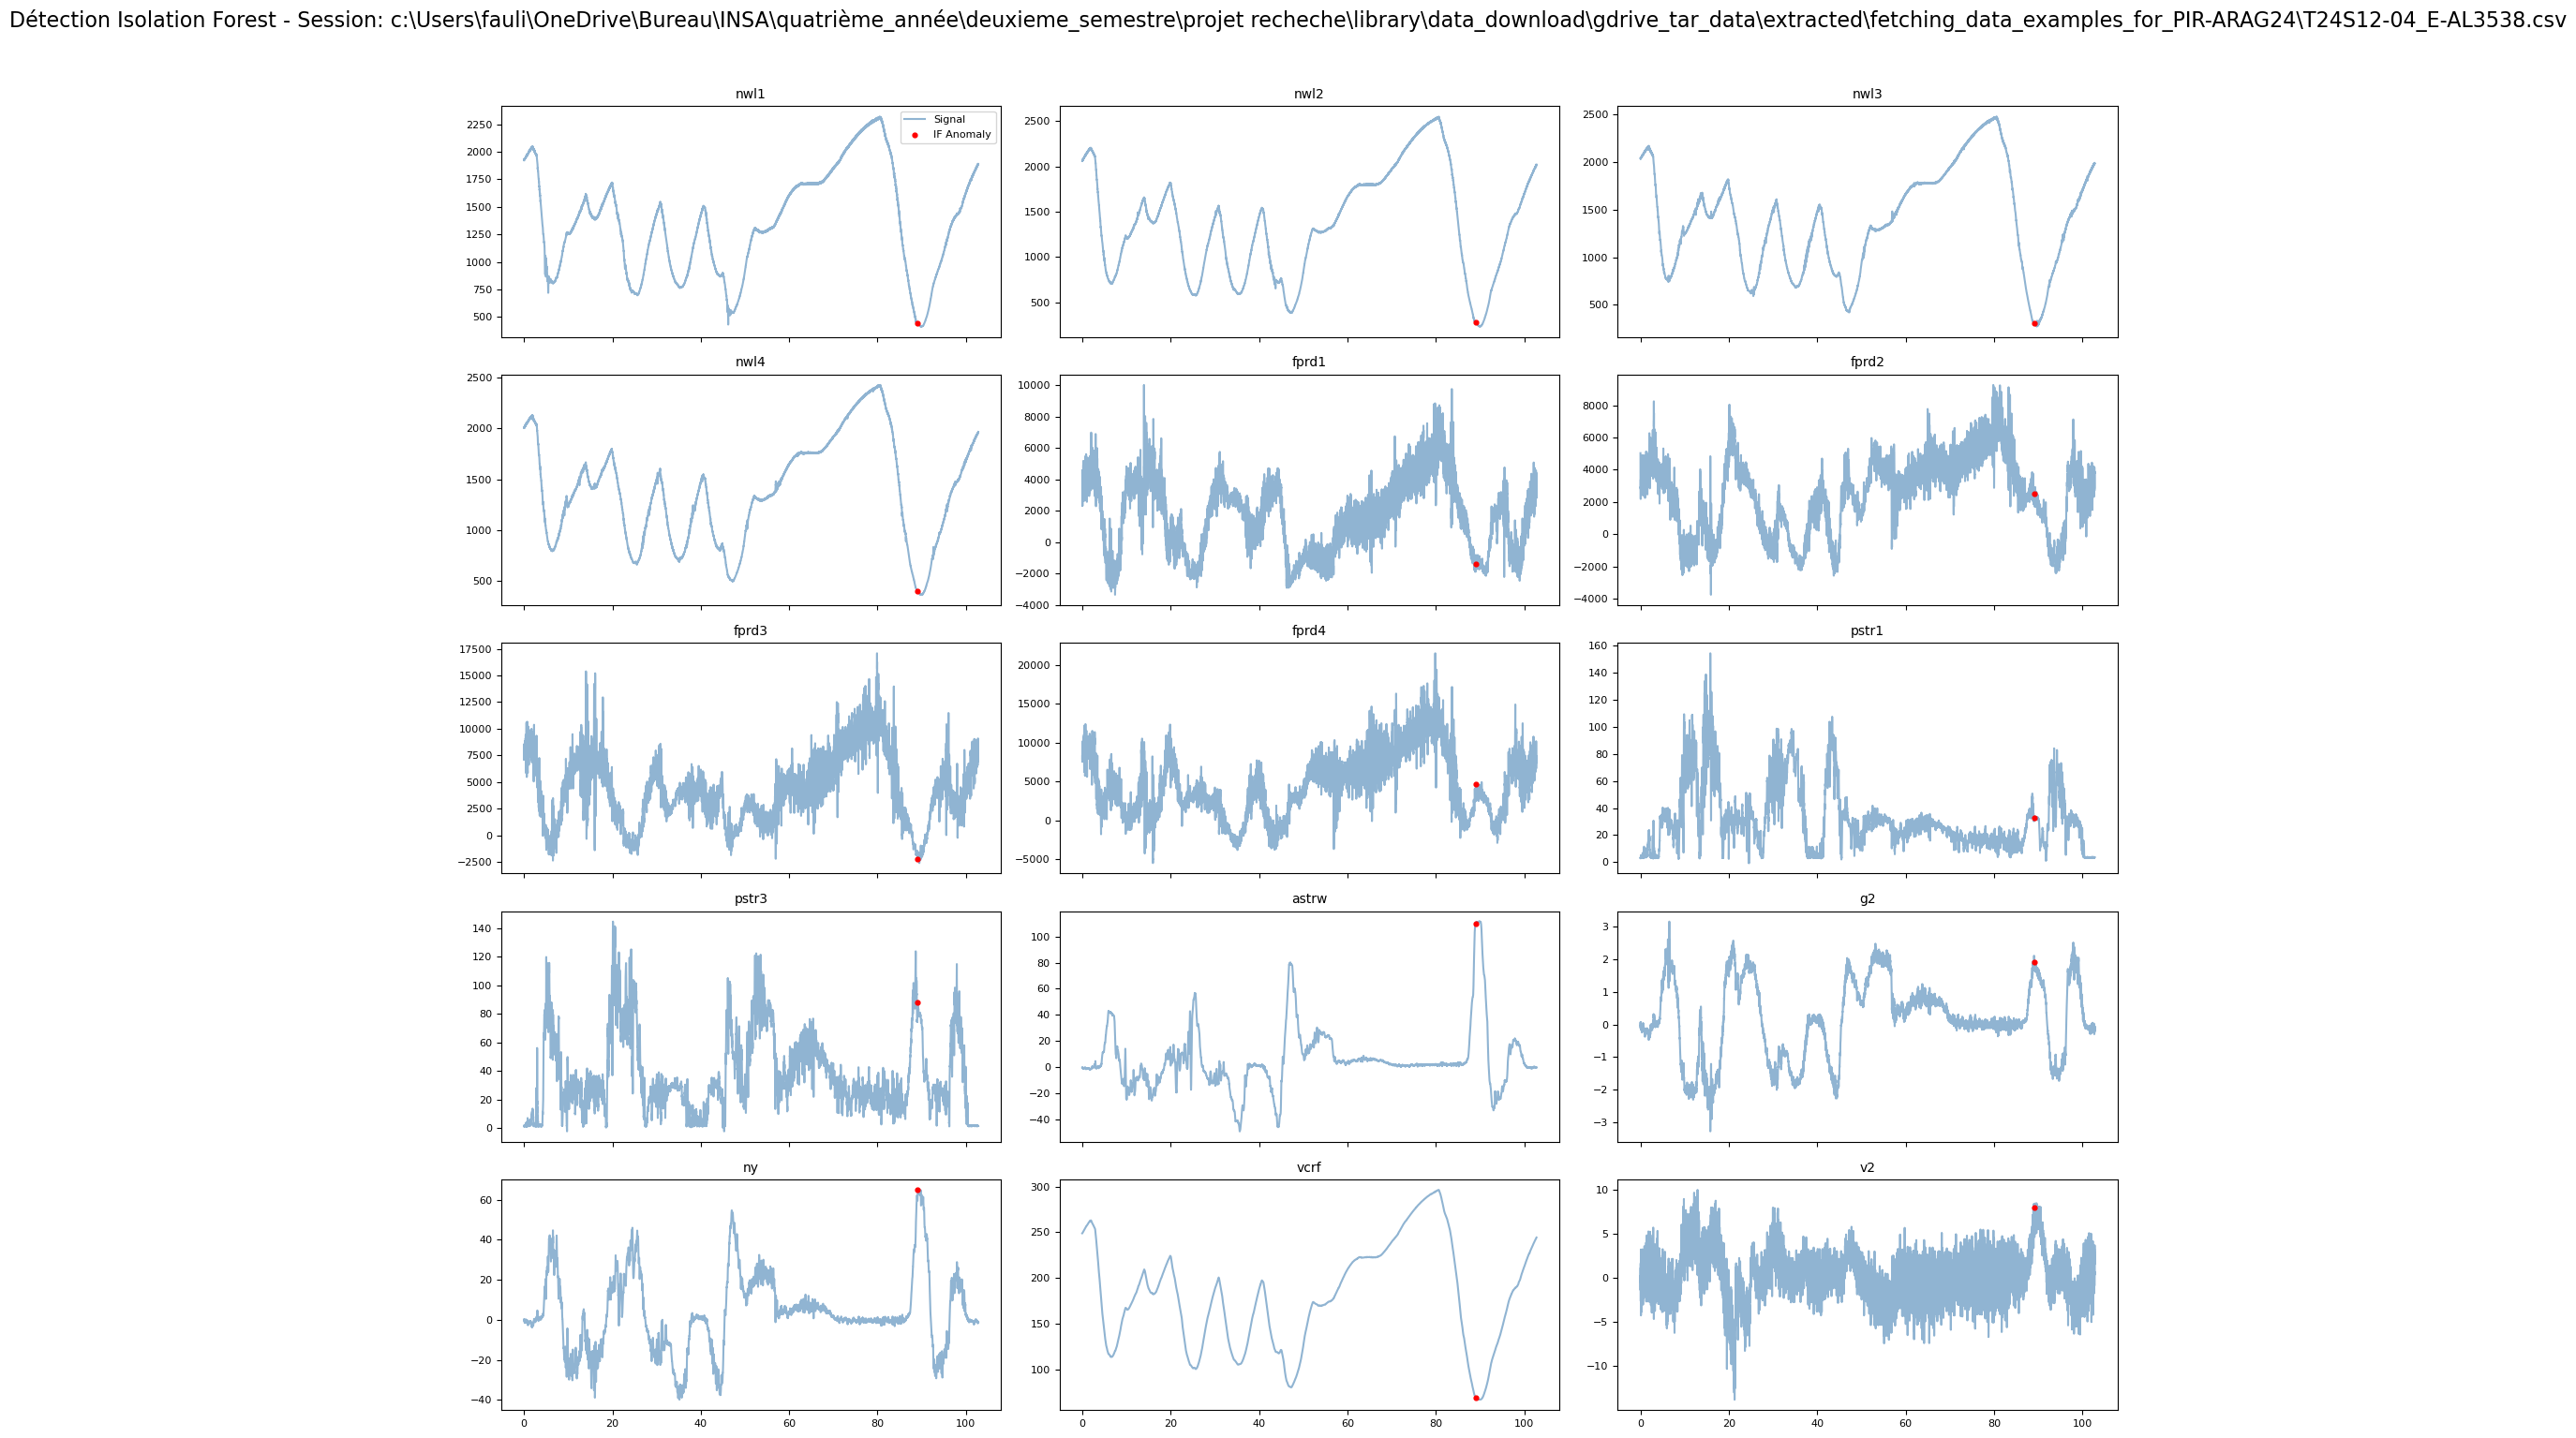

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3438.csv
Detection rate : 1.00%


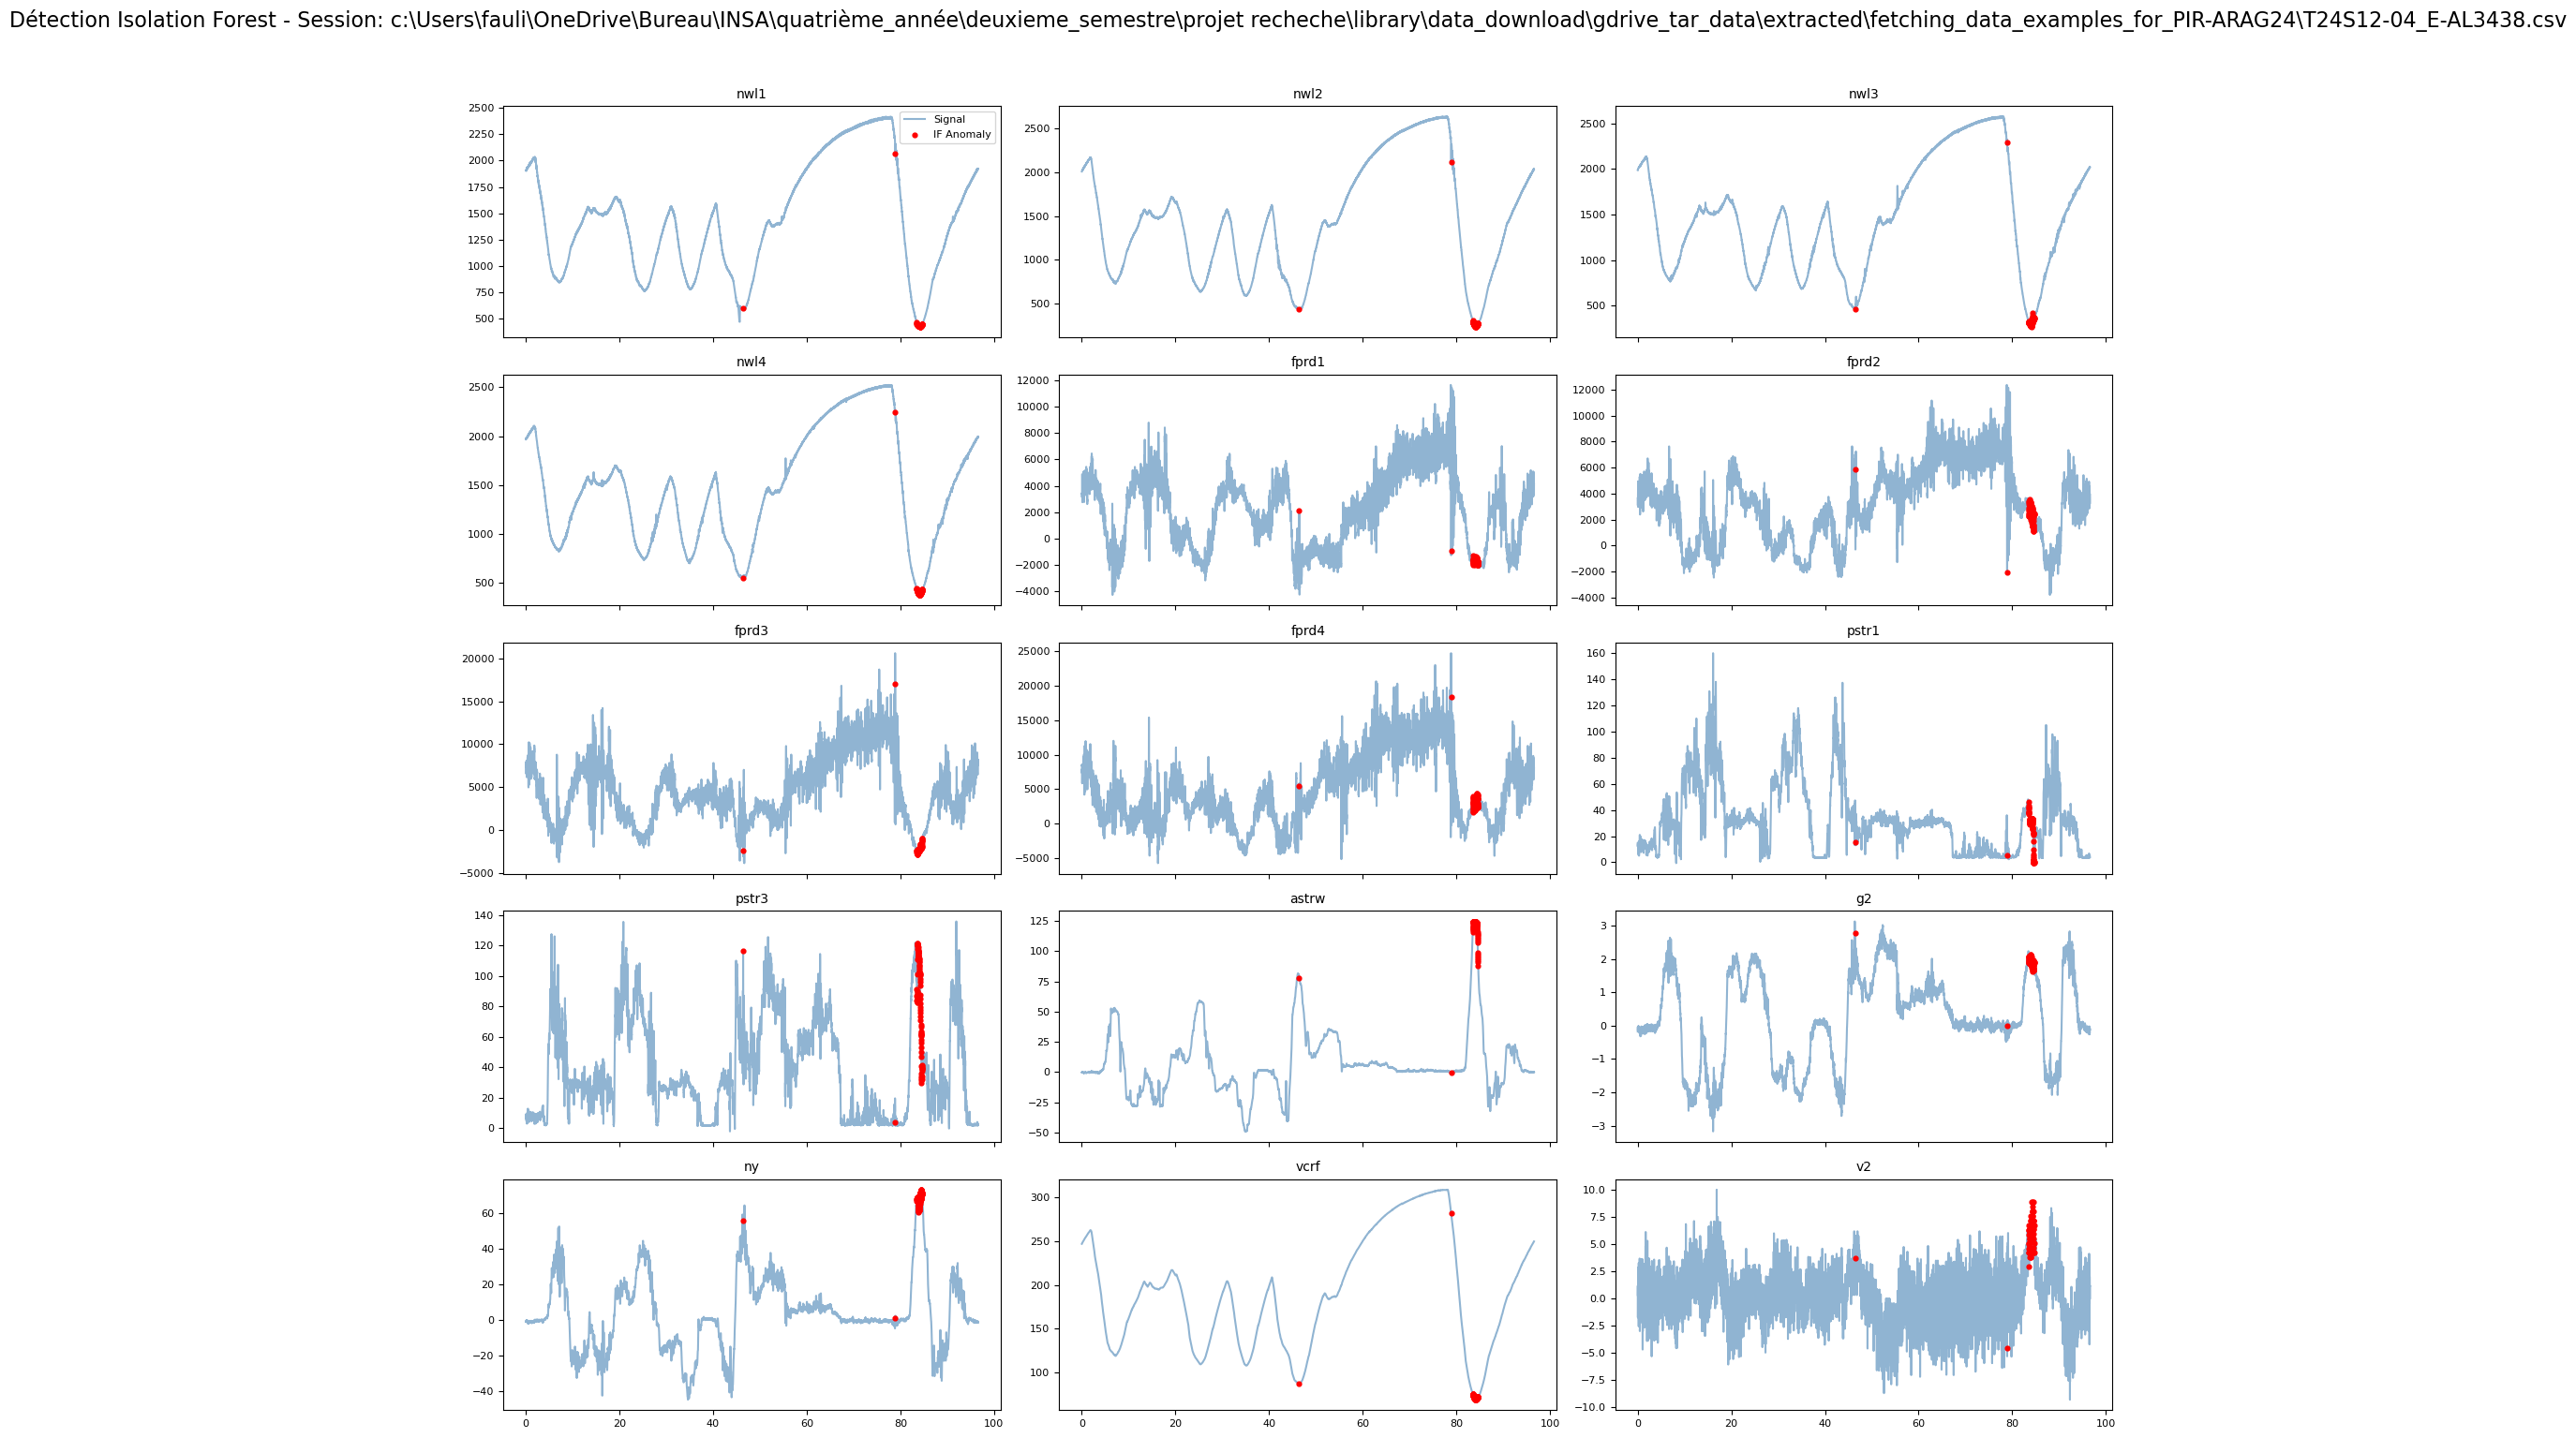

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3377.csv
Detection rate : 1.80%


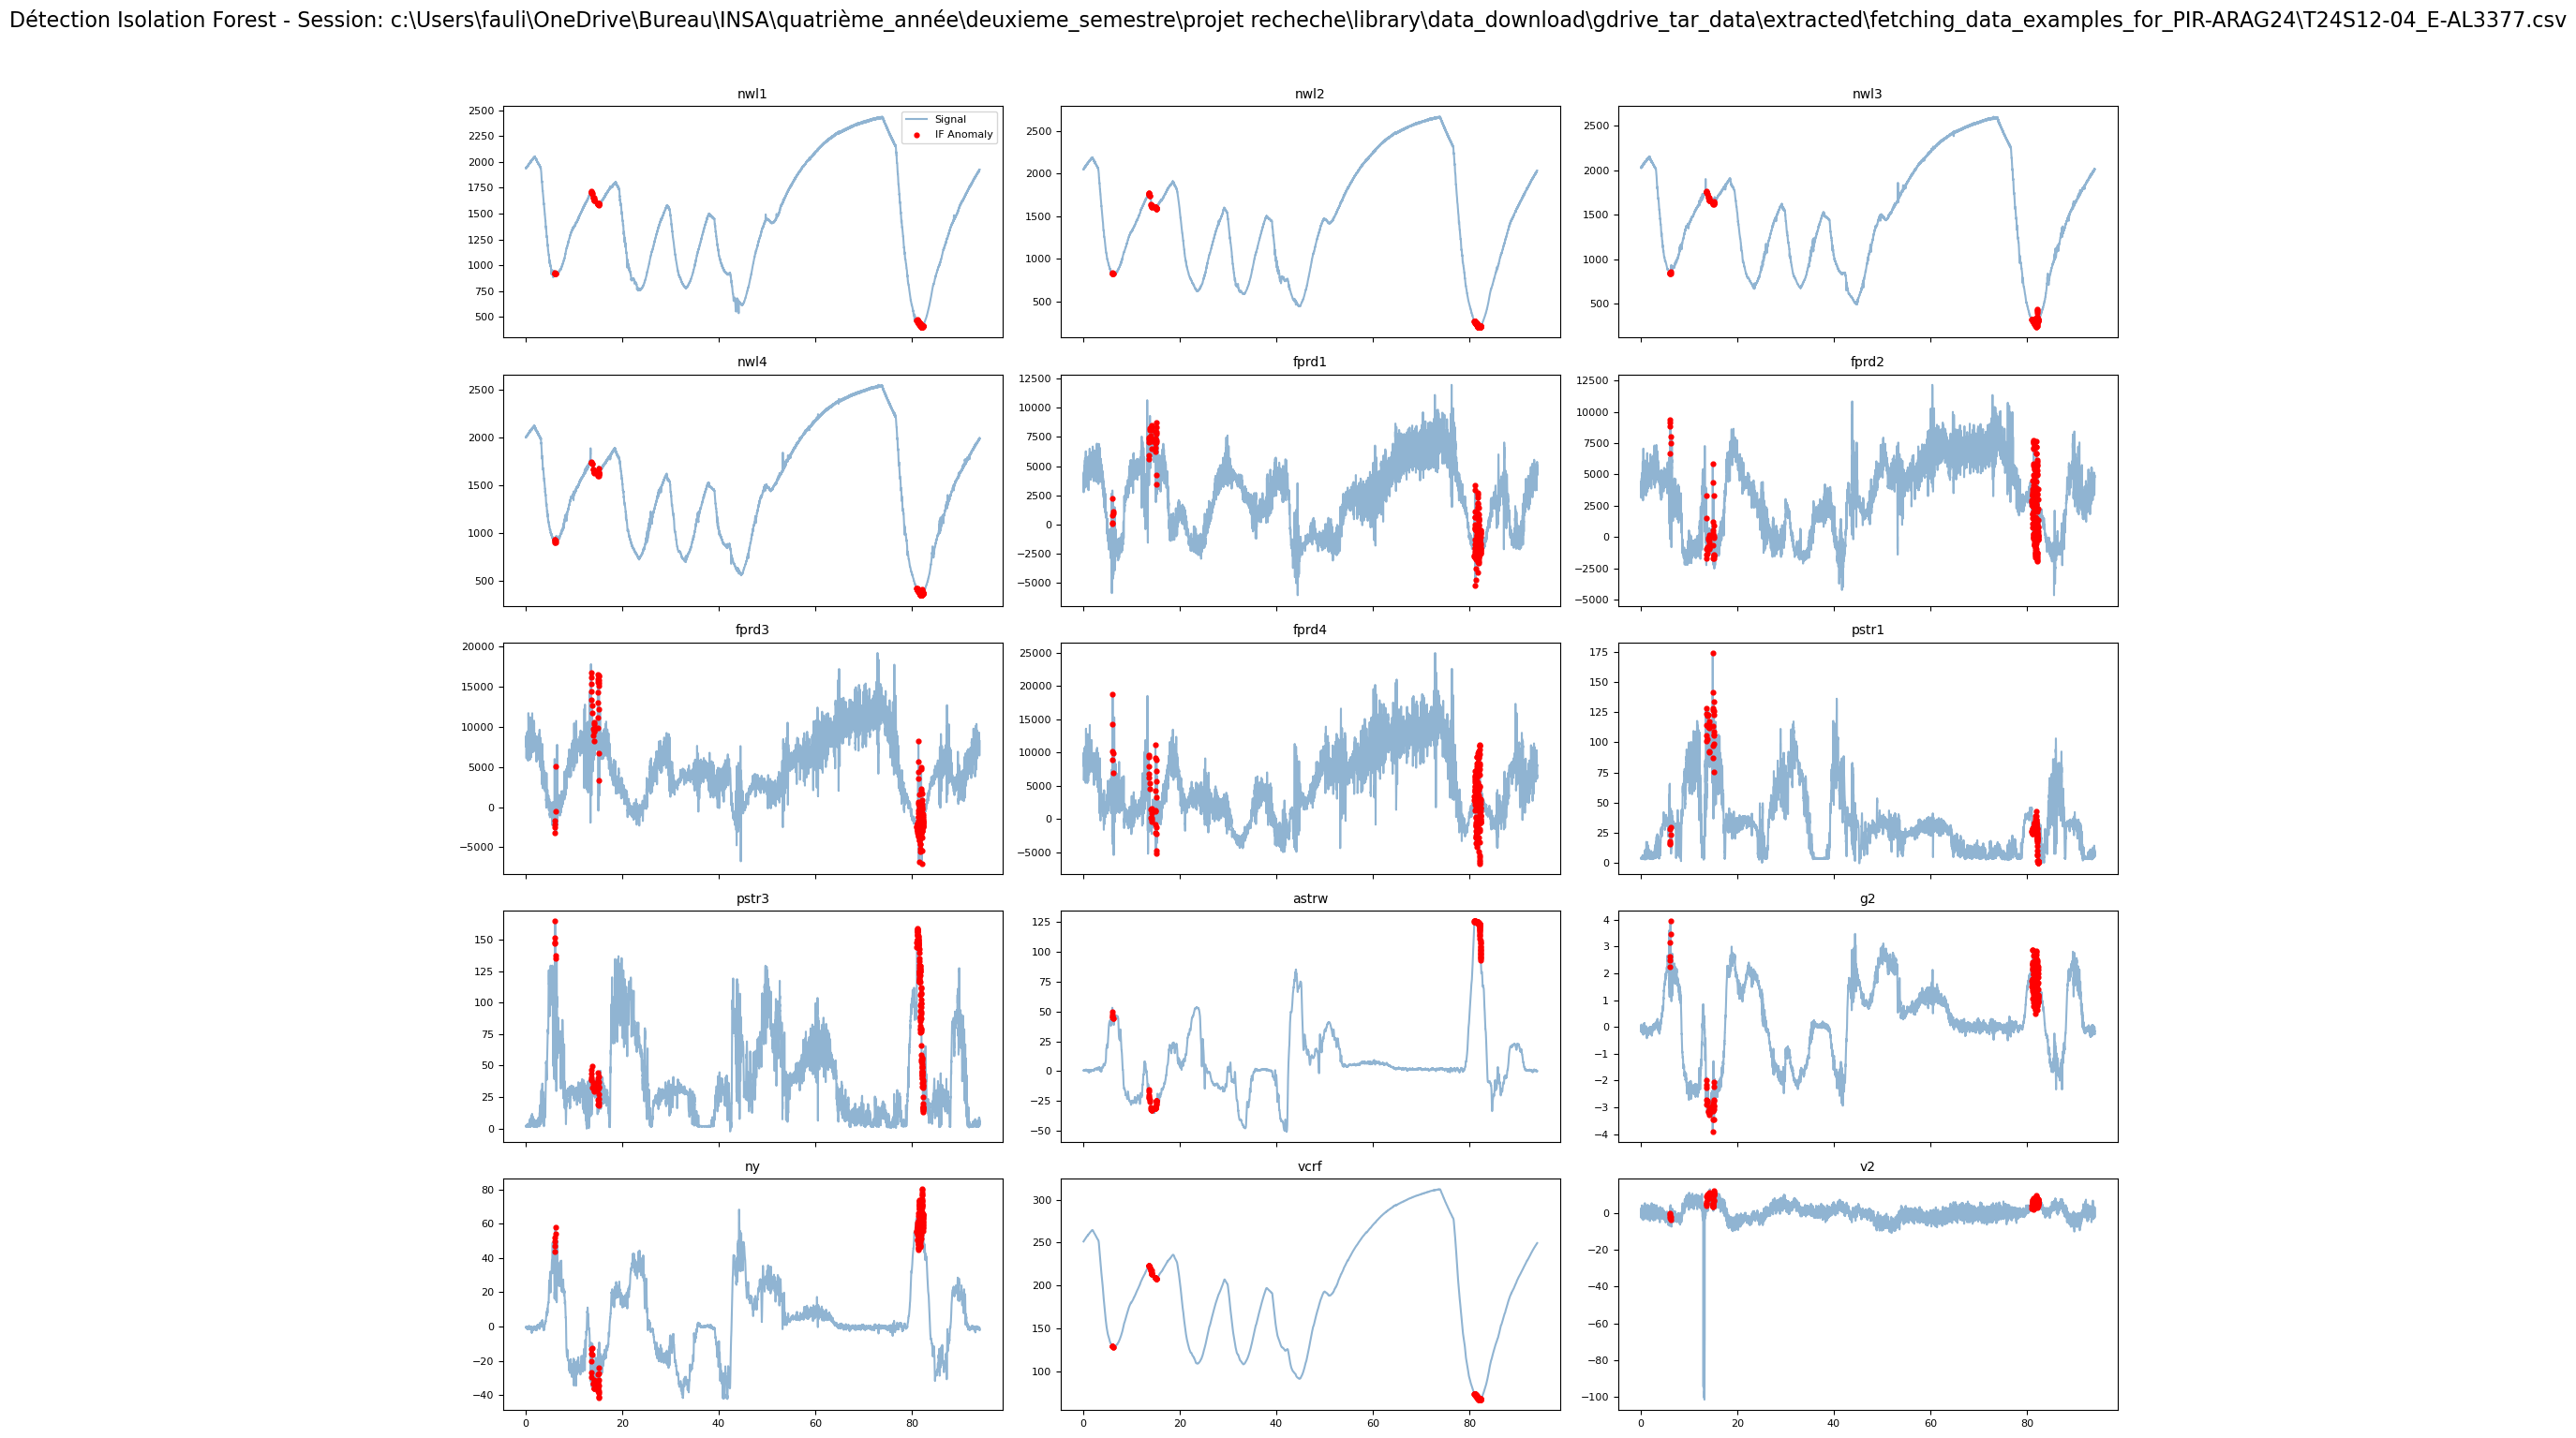

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3014.csv
Detection rate : 0.62%


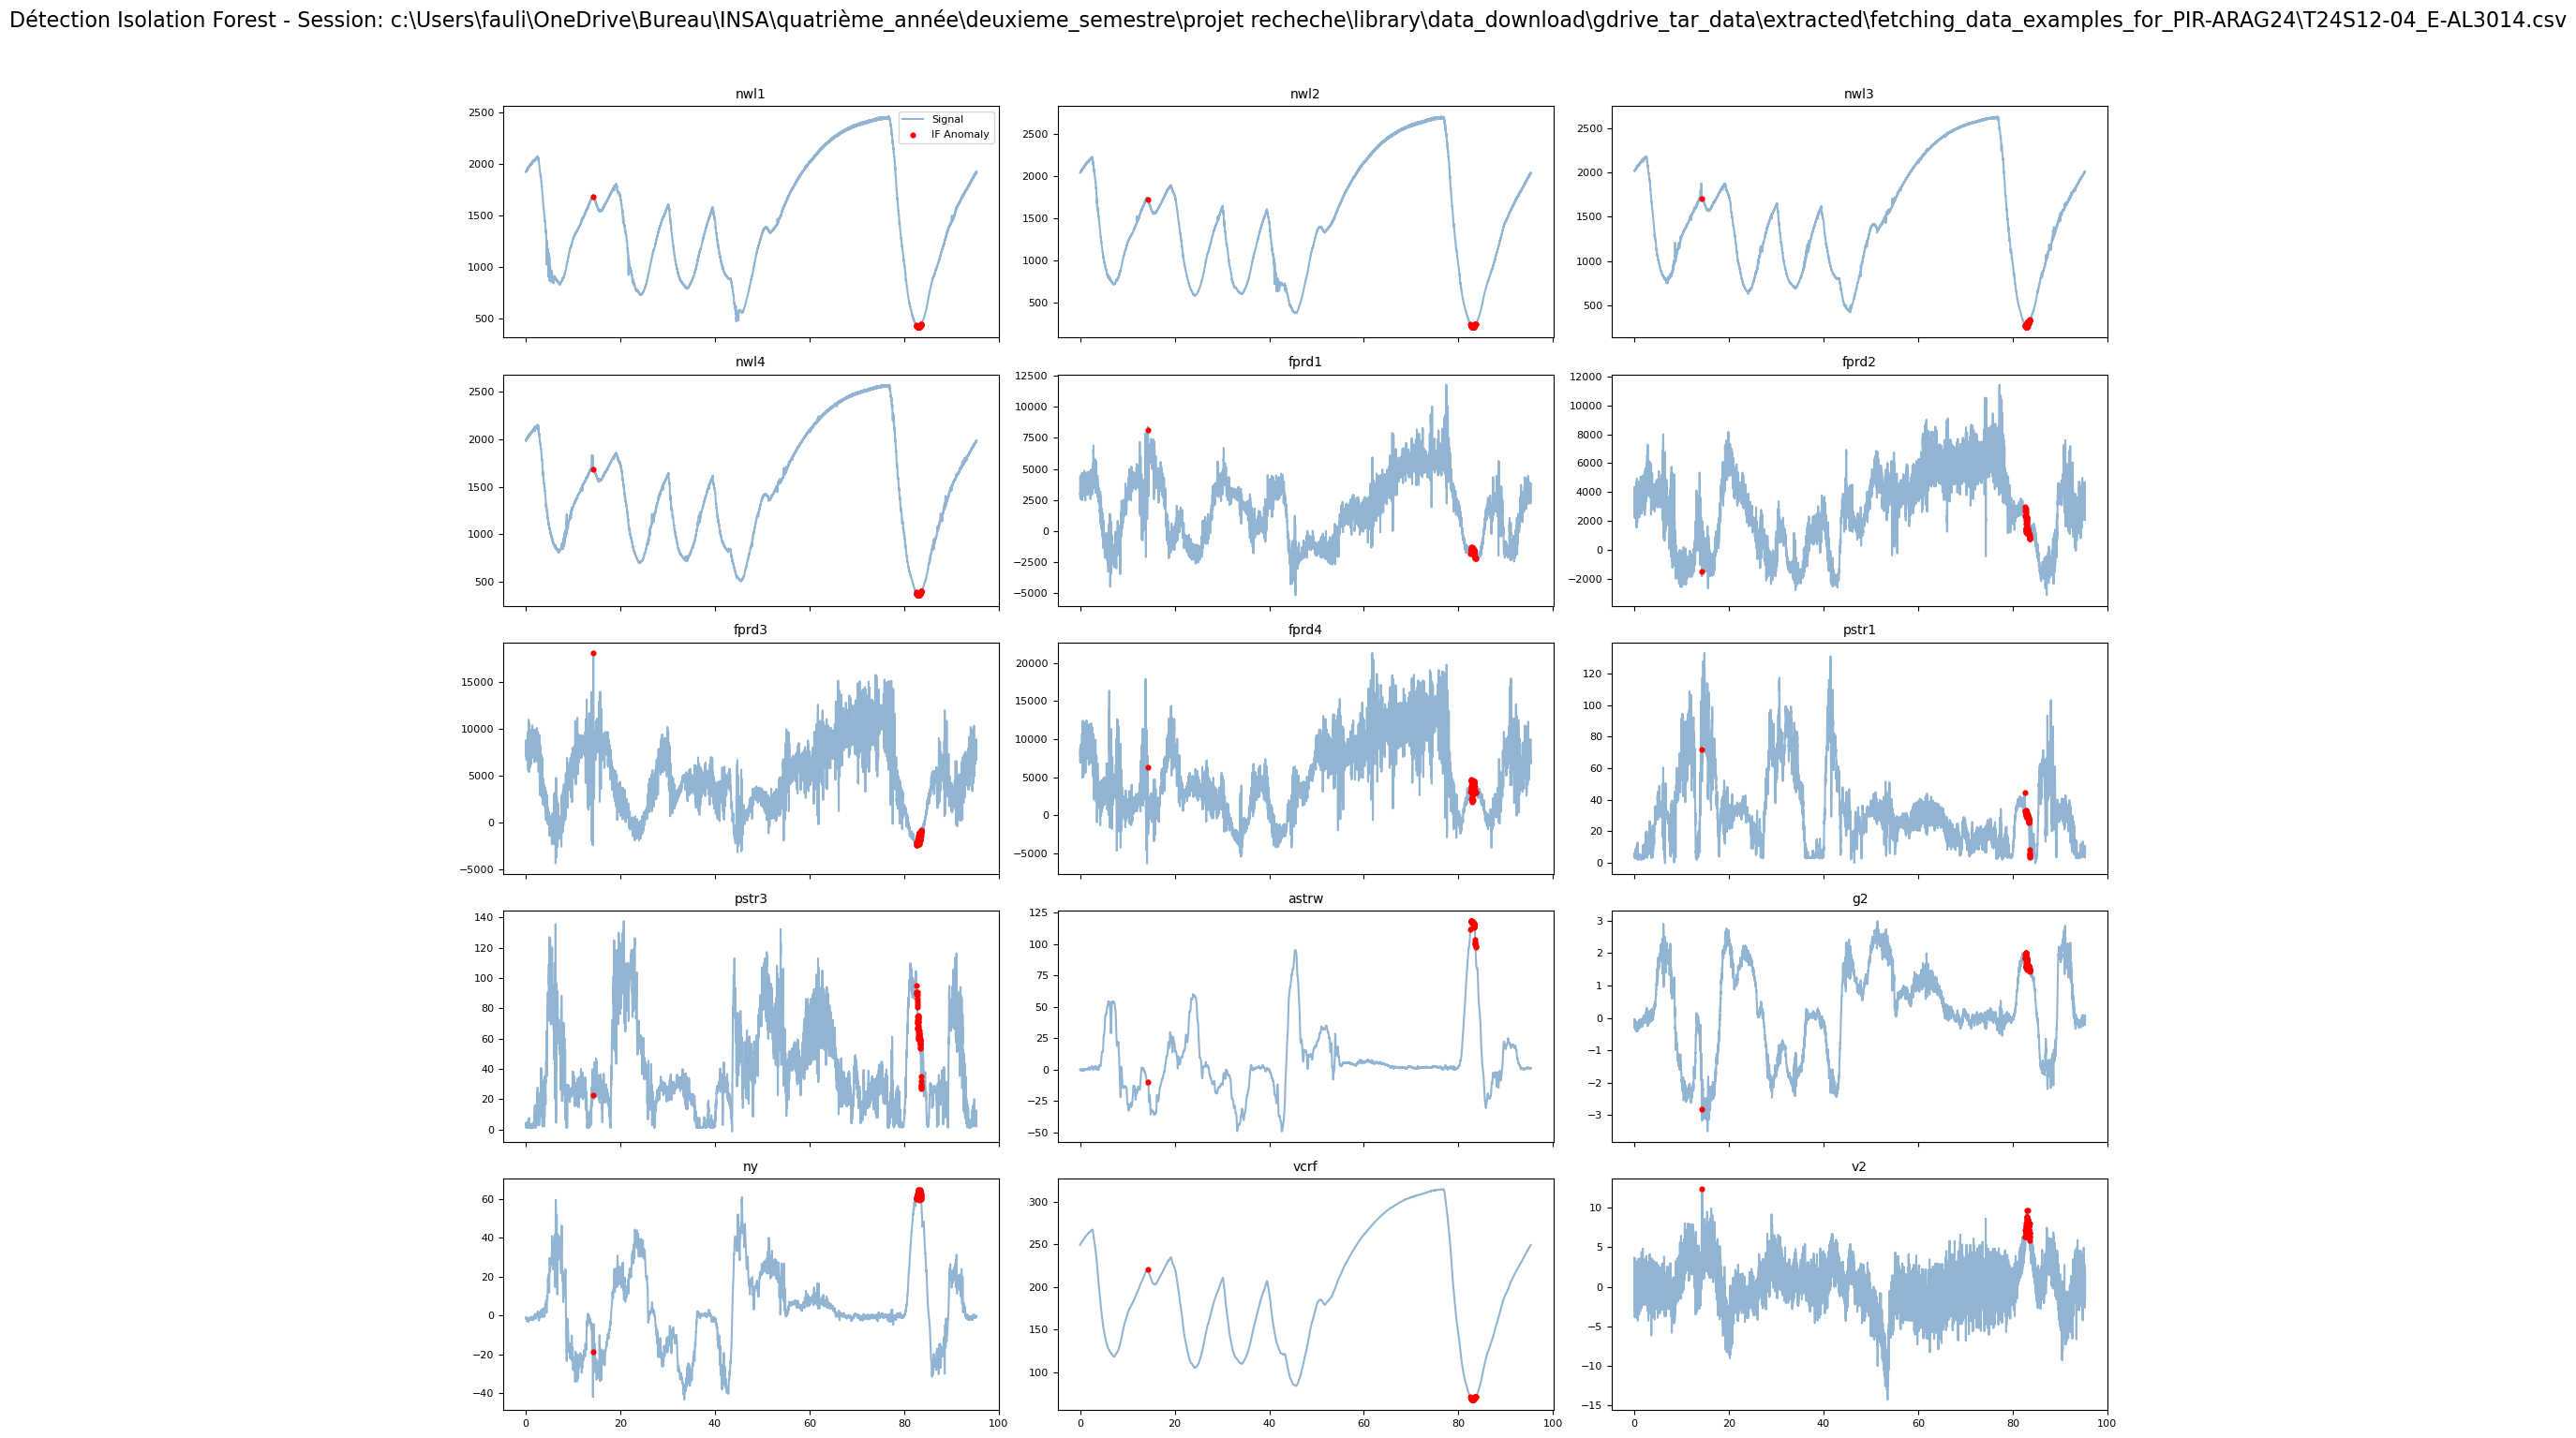

 Session : c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24\T24S12-04_E-AL3221.csv
Detection rate : 0.45%


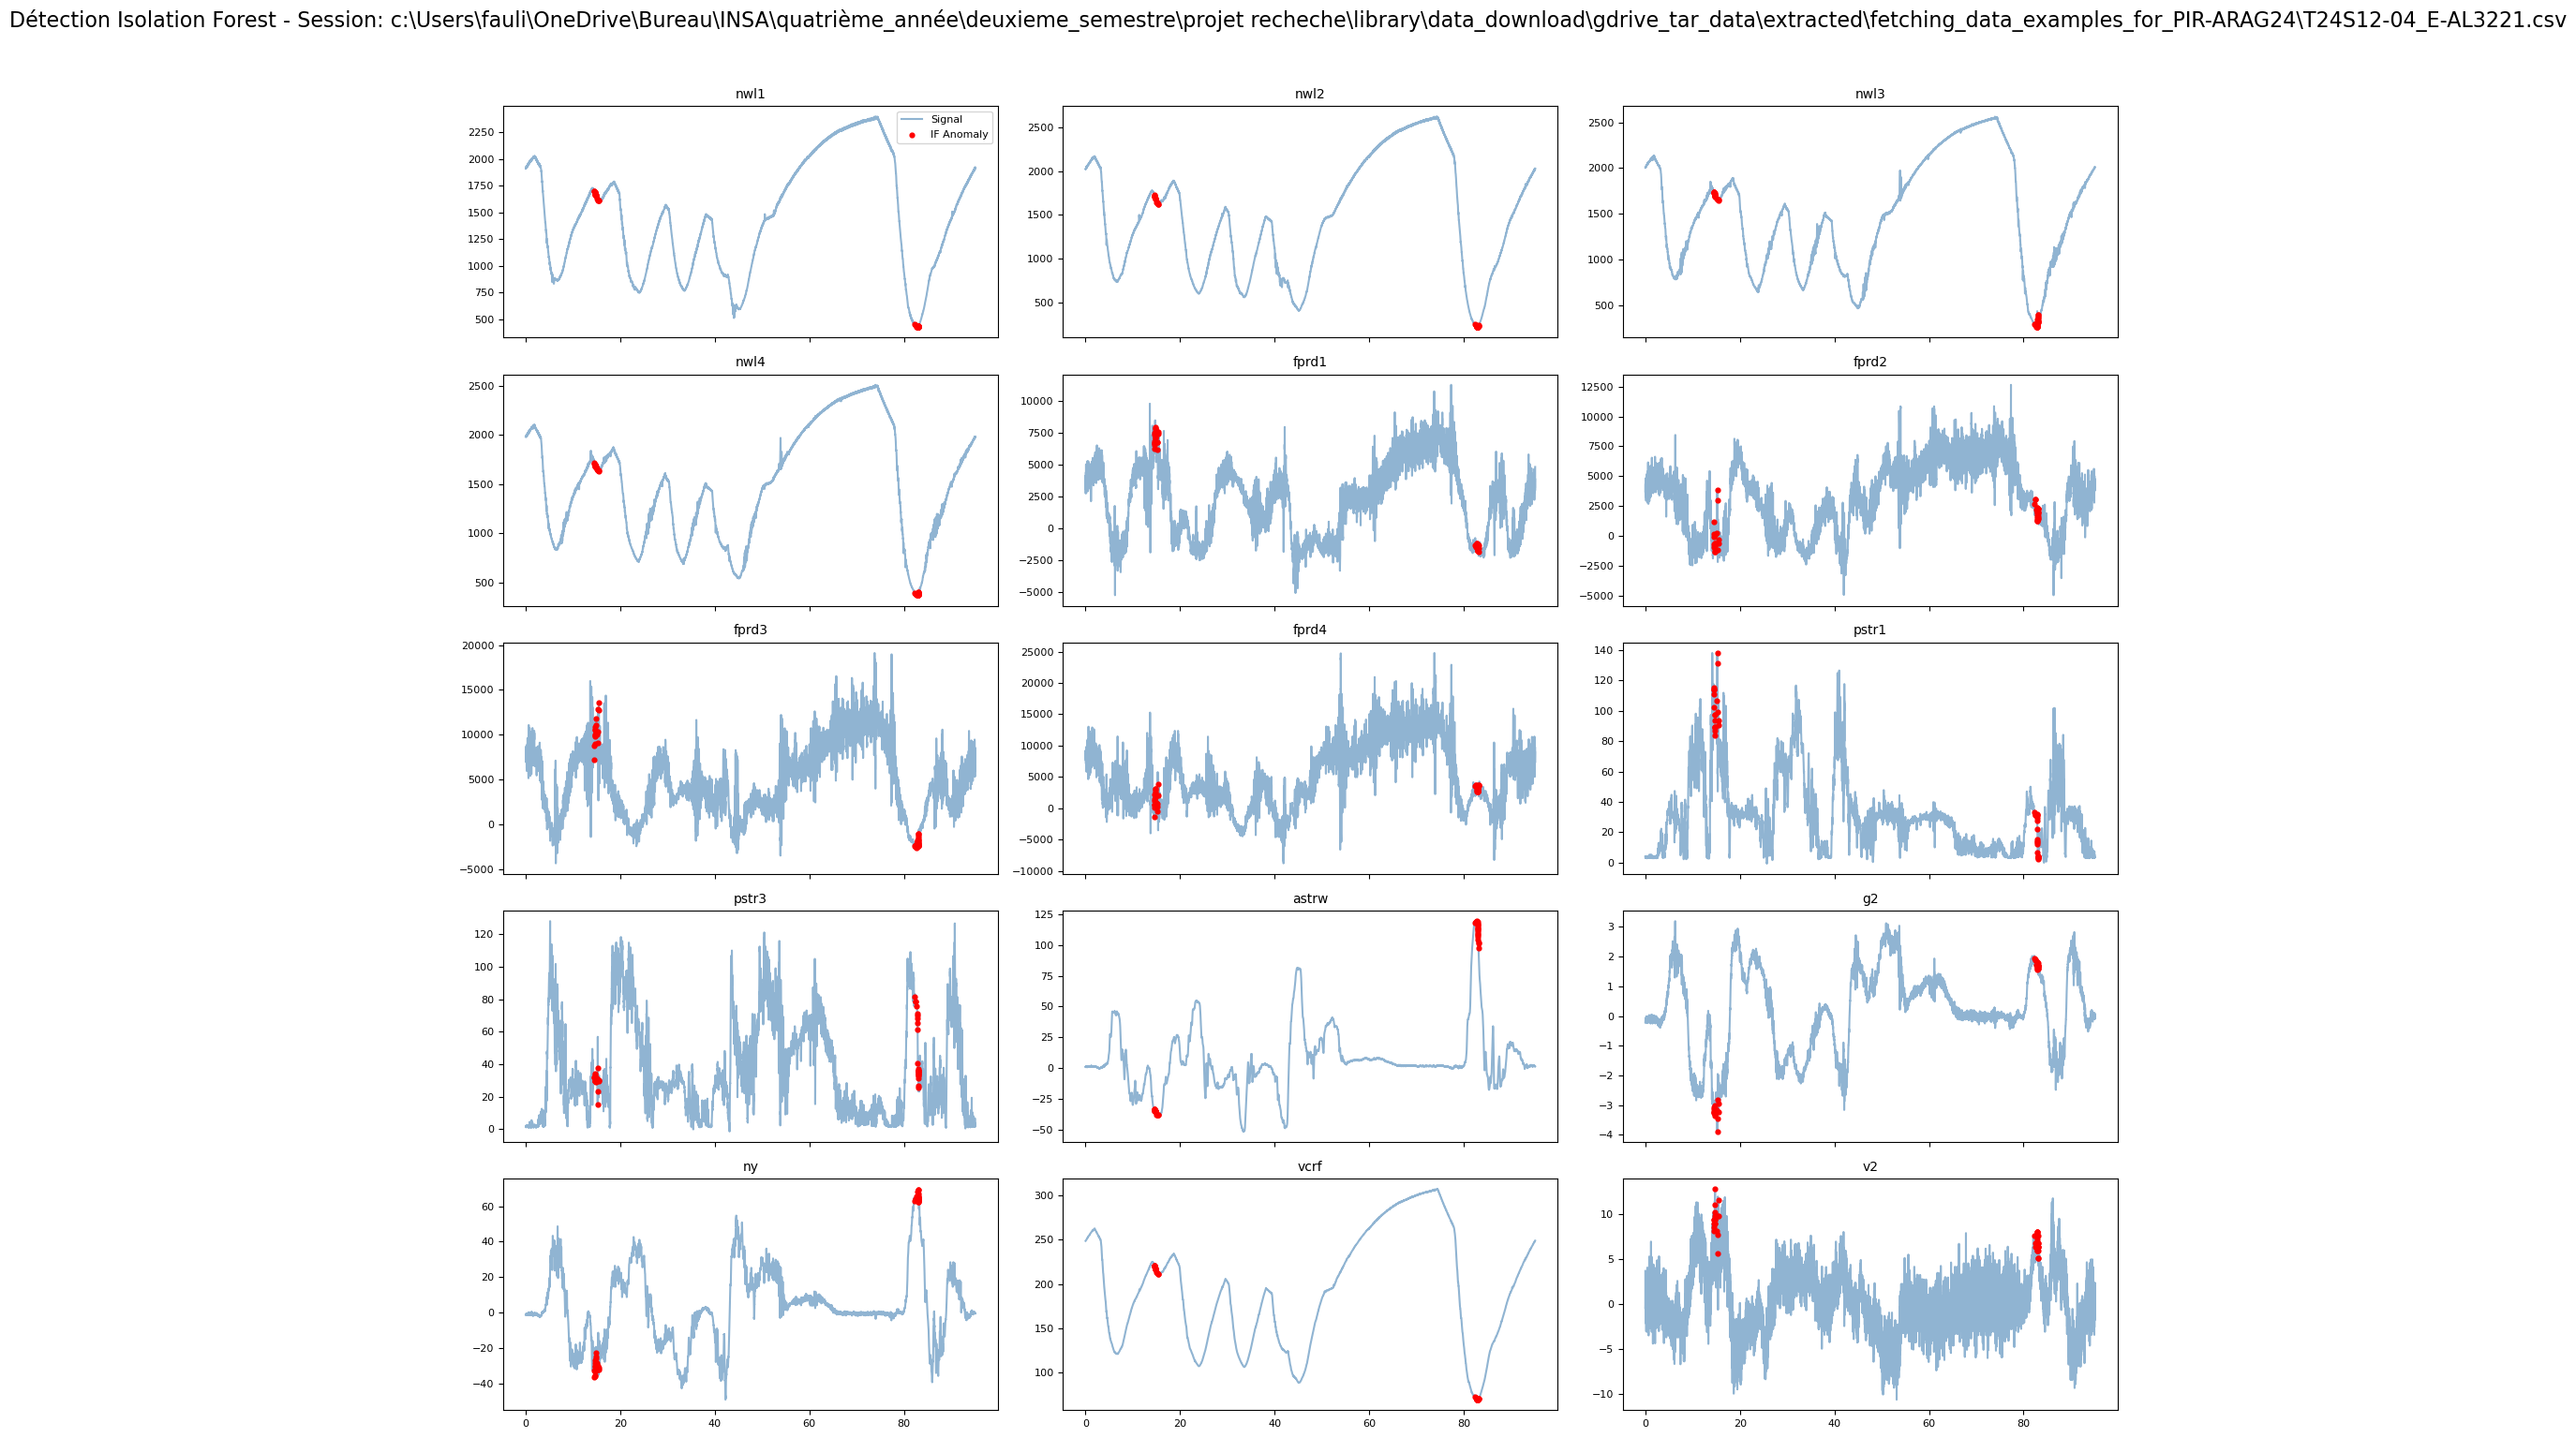

In [ ]:

#test and print the result of the algorithm on each session of the test dataset
for name in list_test:
    id_panne_complet = [k for k in data_dict.keys() if name in k][0]

    df_panne = data_dict[id_panne_complet].copy()
    df_panne = preprocessing.clean_dataframe(df_panne)
    results_panne = clf_if.predict_anomalies(df_panne)
    #Print the result
    print(f" Session : {name}")
    print(f"Detection rate : {results_panne['anomaly_detected'].mean() * 100:.2f}%")

    df_plot = results_panne.copy()
    anomaly_mask = df_plot['anomaly_detected'] == 1
    anomaly_times = df_plot.loc[anomaly_mask, 'time_real']

# Select only the sensors 
    cols_to_show = features[:15] 

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 15), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(cols_to_show):
        ax = axes[i]
        
        # Draw the original signal
        ax.plot(df_plot['time_real'], df_plot[col], color='steelblue', alpha=0.6, label='Signal')

        # Overlay the anomaly points in red
        ax.scatter(
            anomaly_times,
            df_plot.loc[anomaly_mask, col],
            color='red',
            s=12,
            label='IF Anomaly',
            zorder=3
        )

        ax.set_title(f"{col}", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)


    plt.suptitle(f"Détection Isolation Forest - Session: {name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
#

## Detection on anomalous data

 Session : T24S12-04_E-AL2706
Detection rate : 100.00%


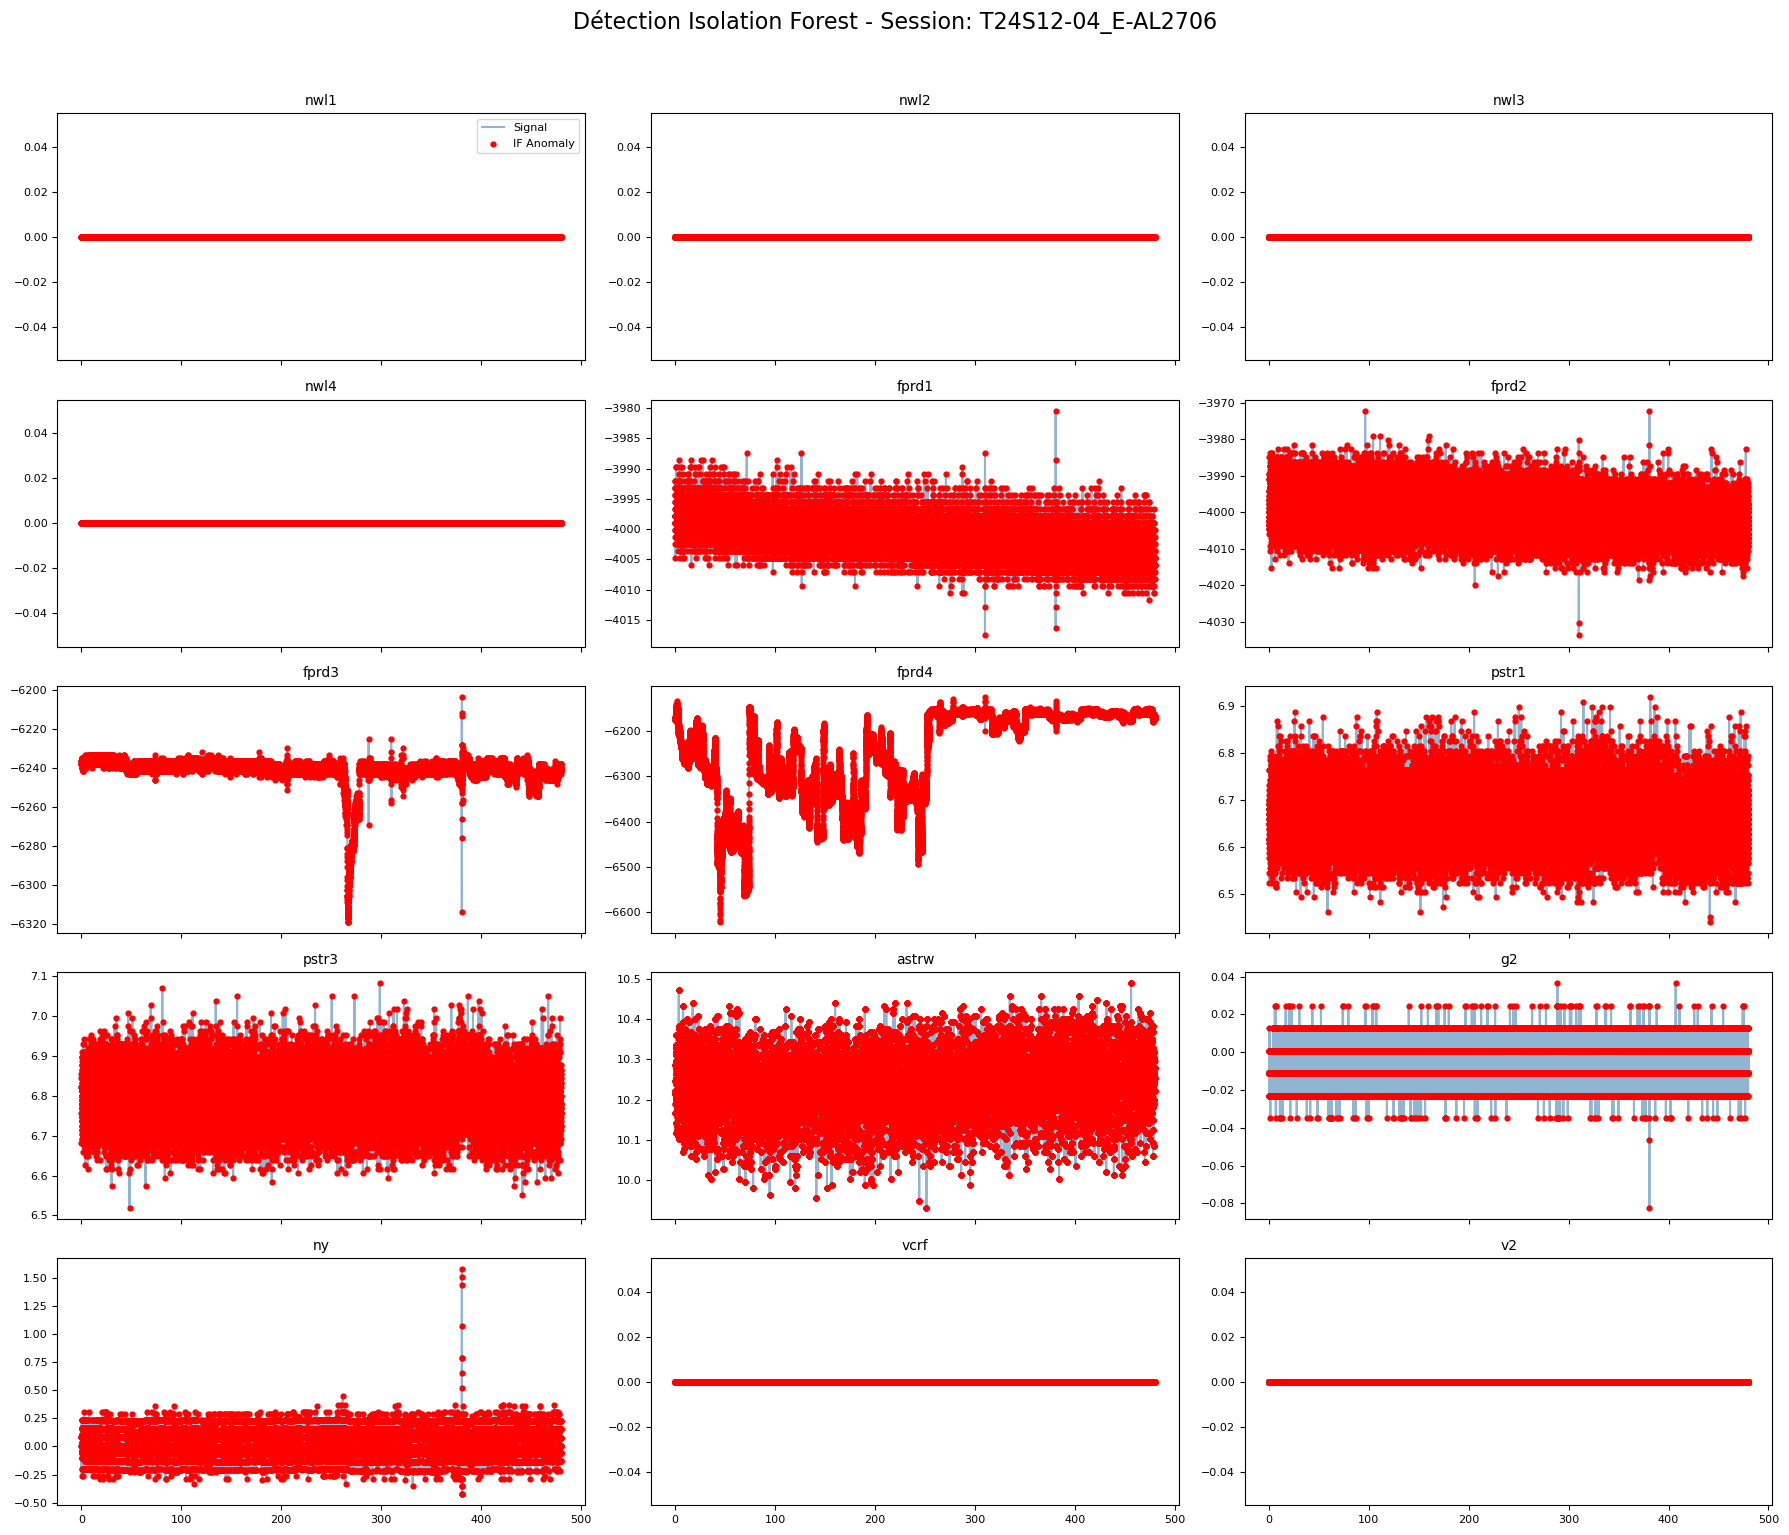

 Session : T24S12-04_E-AL2725
Detection rate : 88.61%


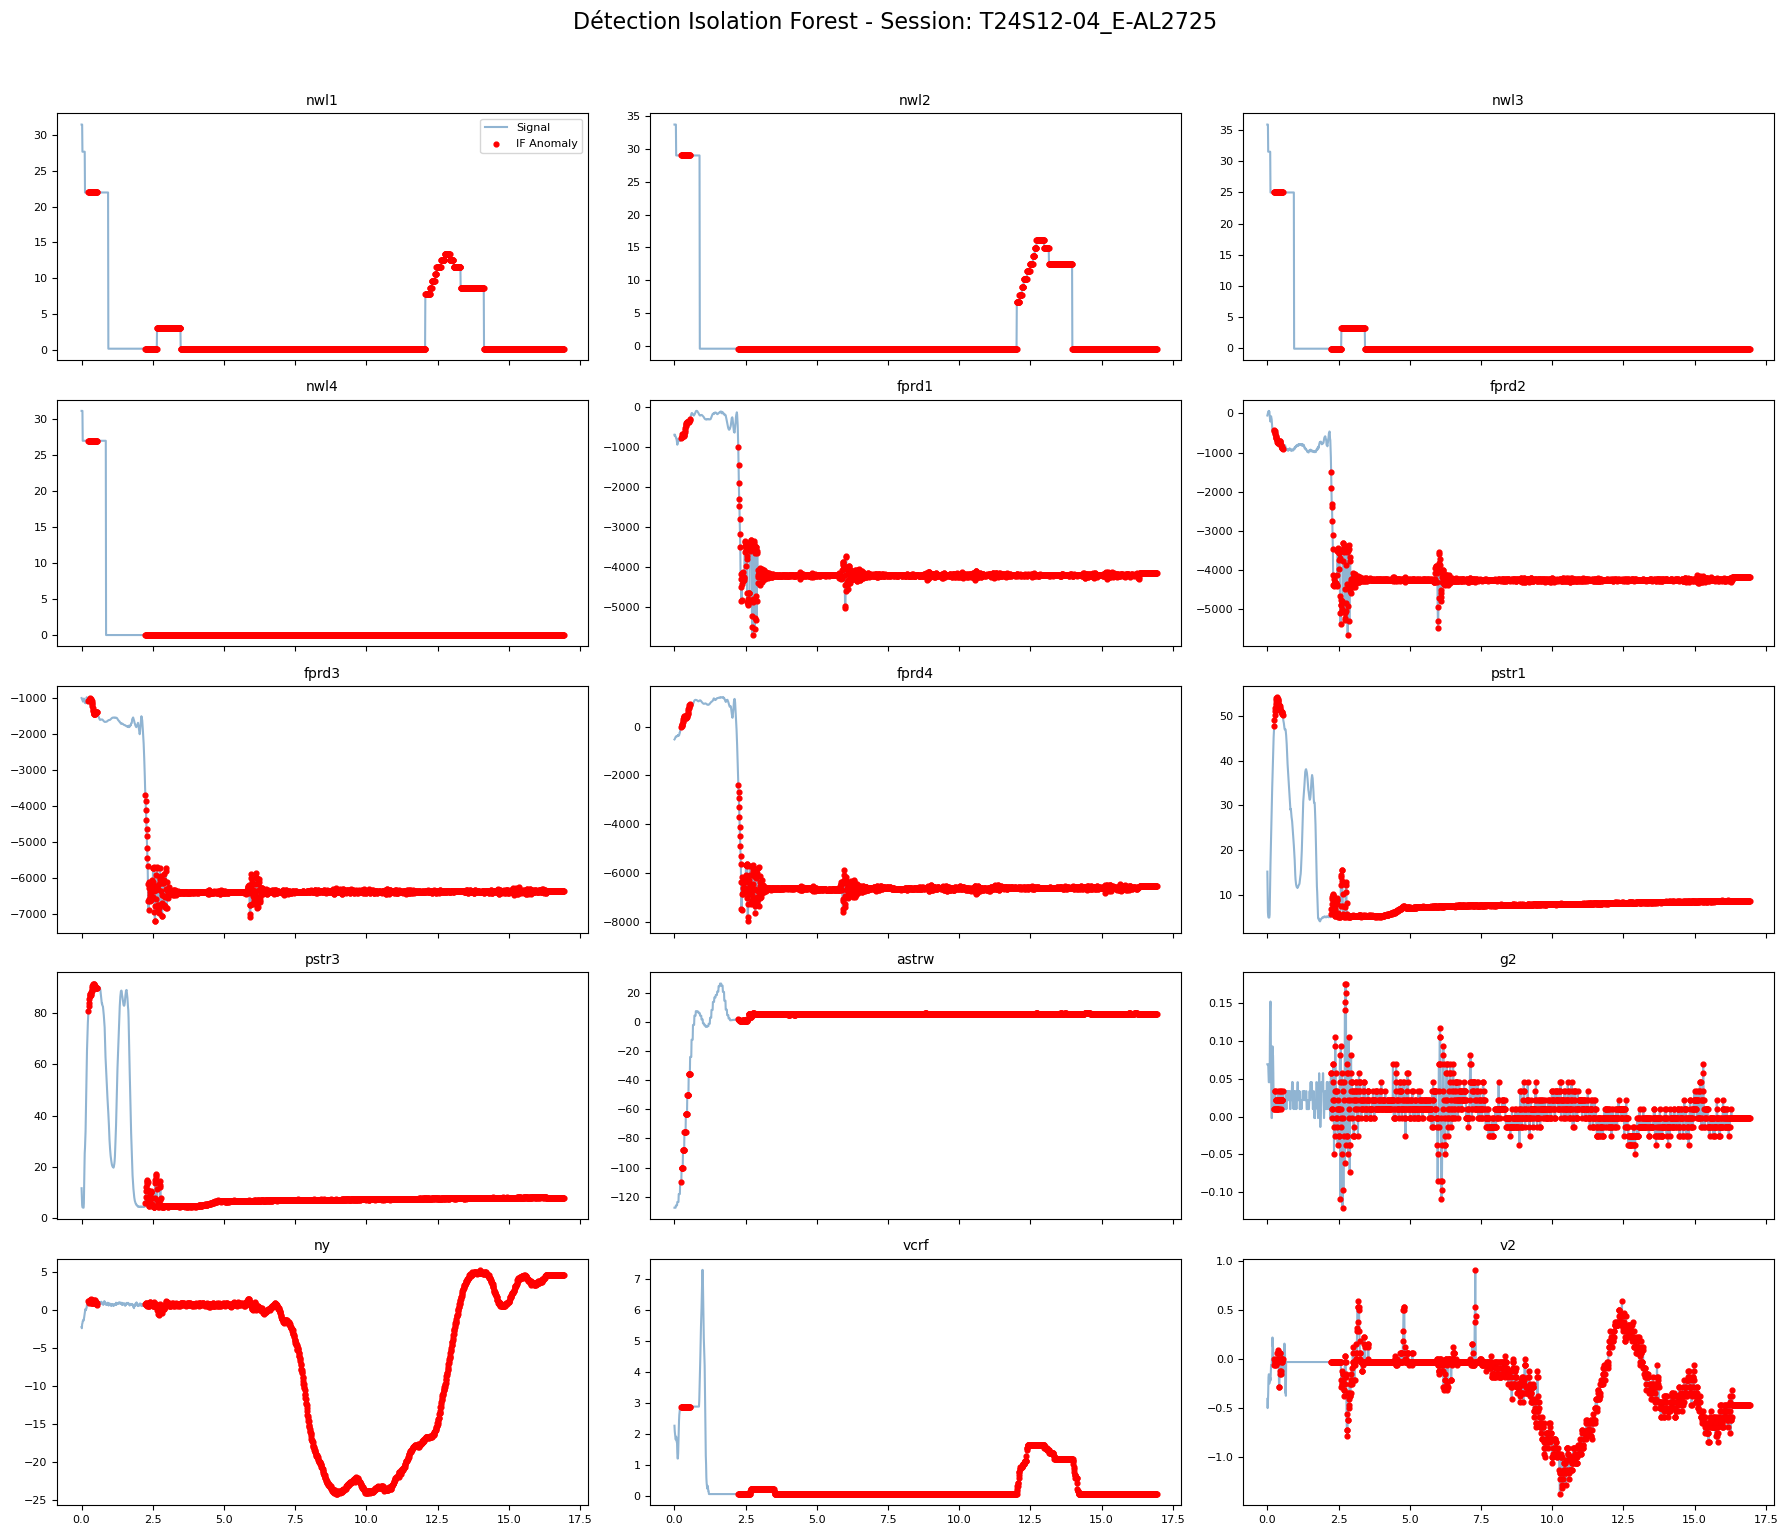

 Session : T24S12-04_E-AL2761
Detection rate : 100.00%


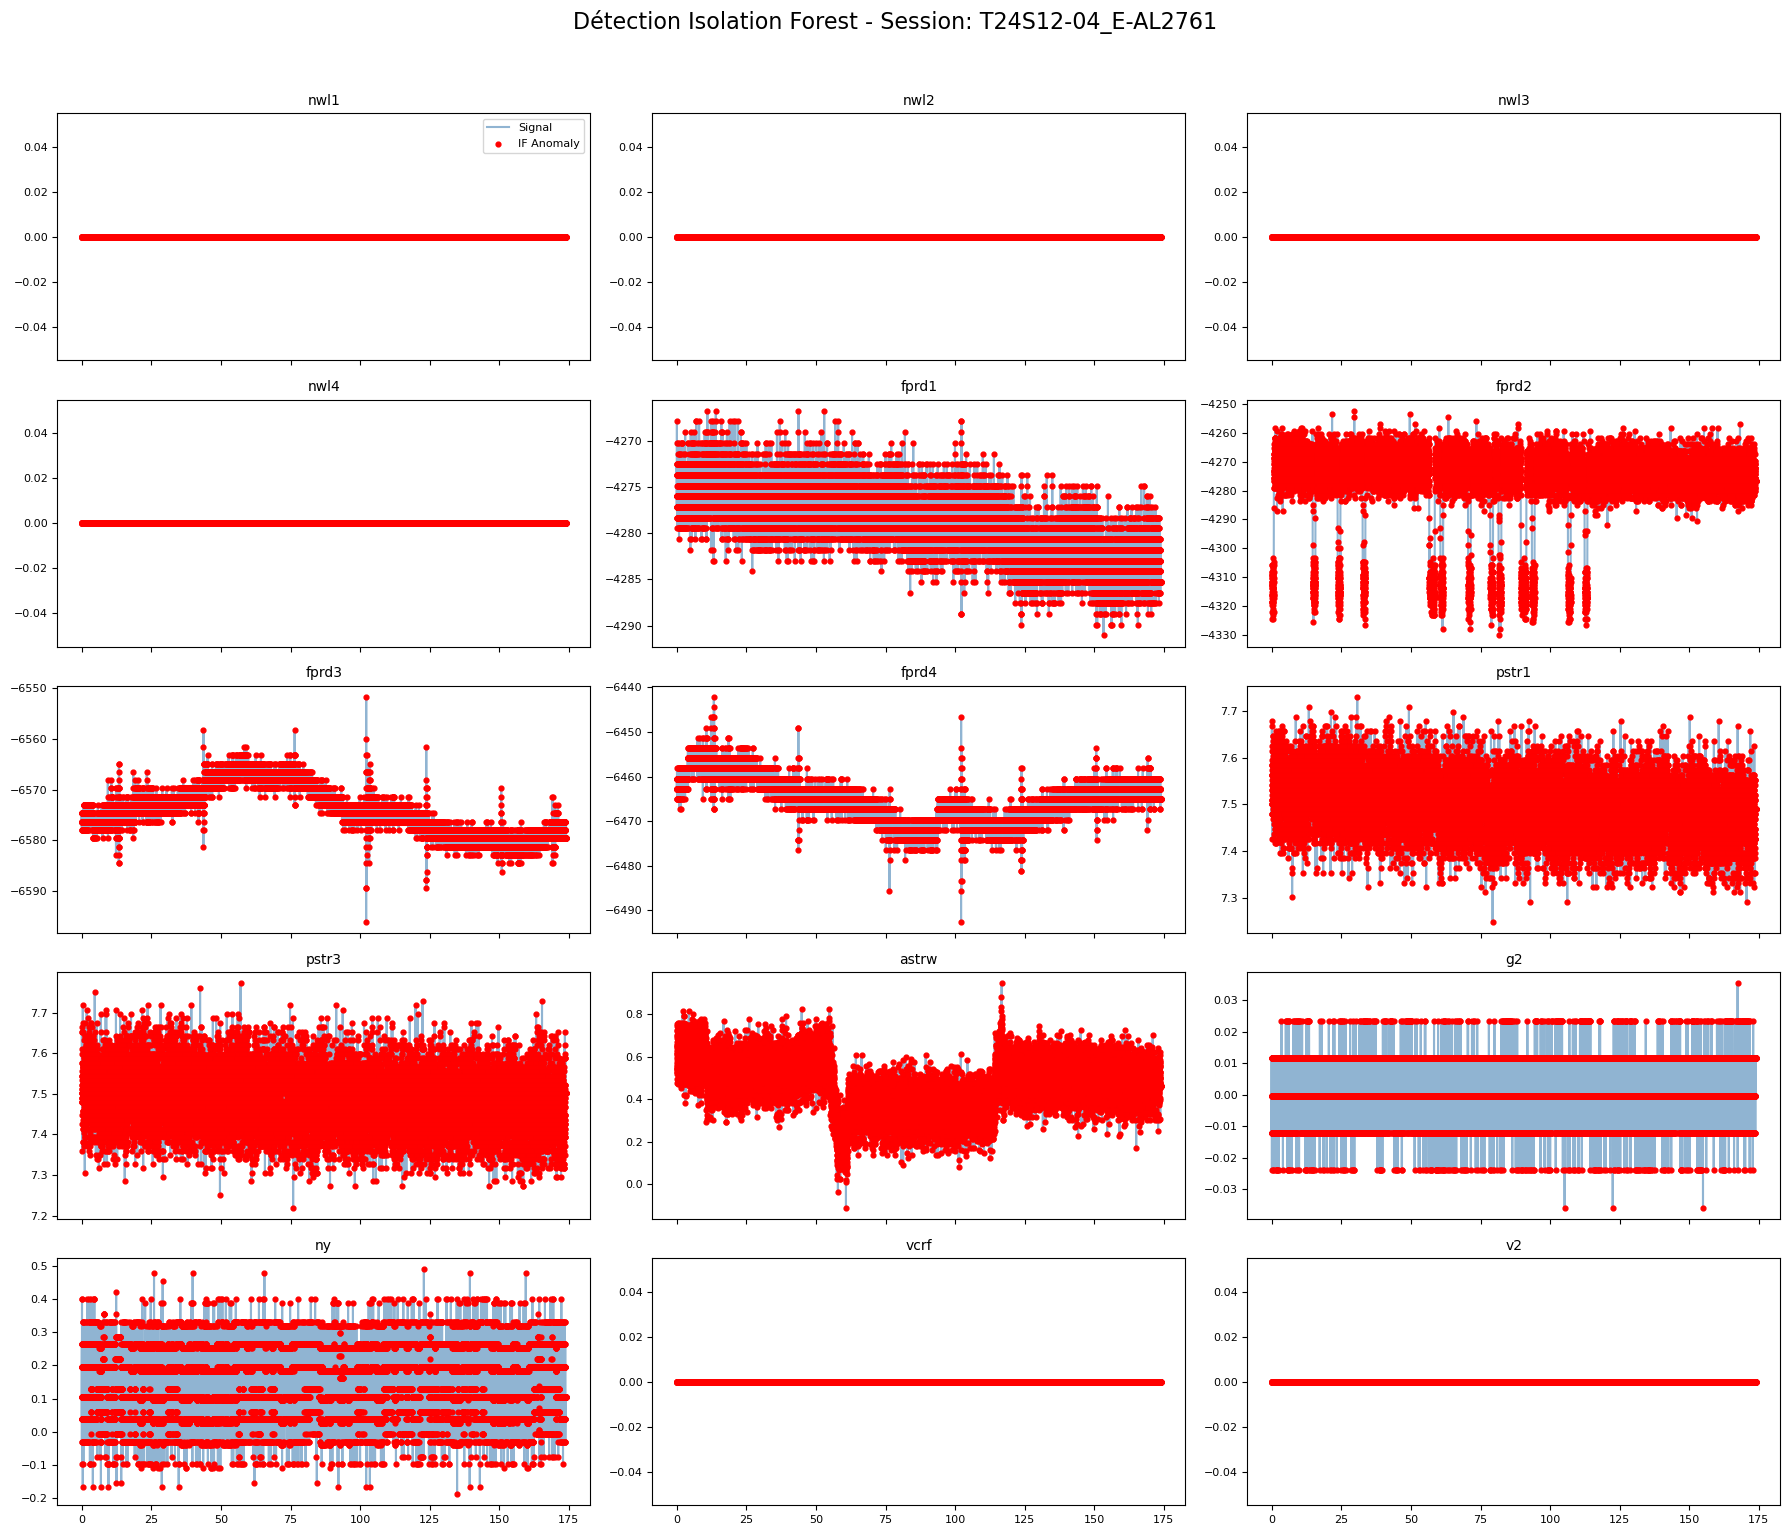

 Session : T24S12-04_E-AL2780
Detection rate : 1.86%


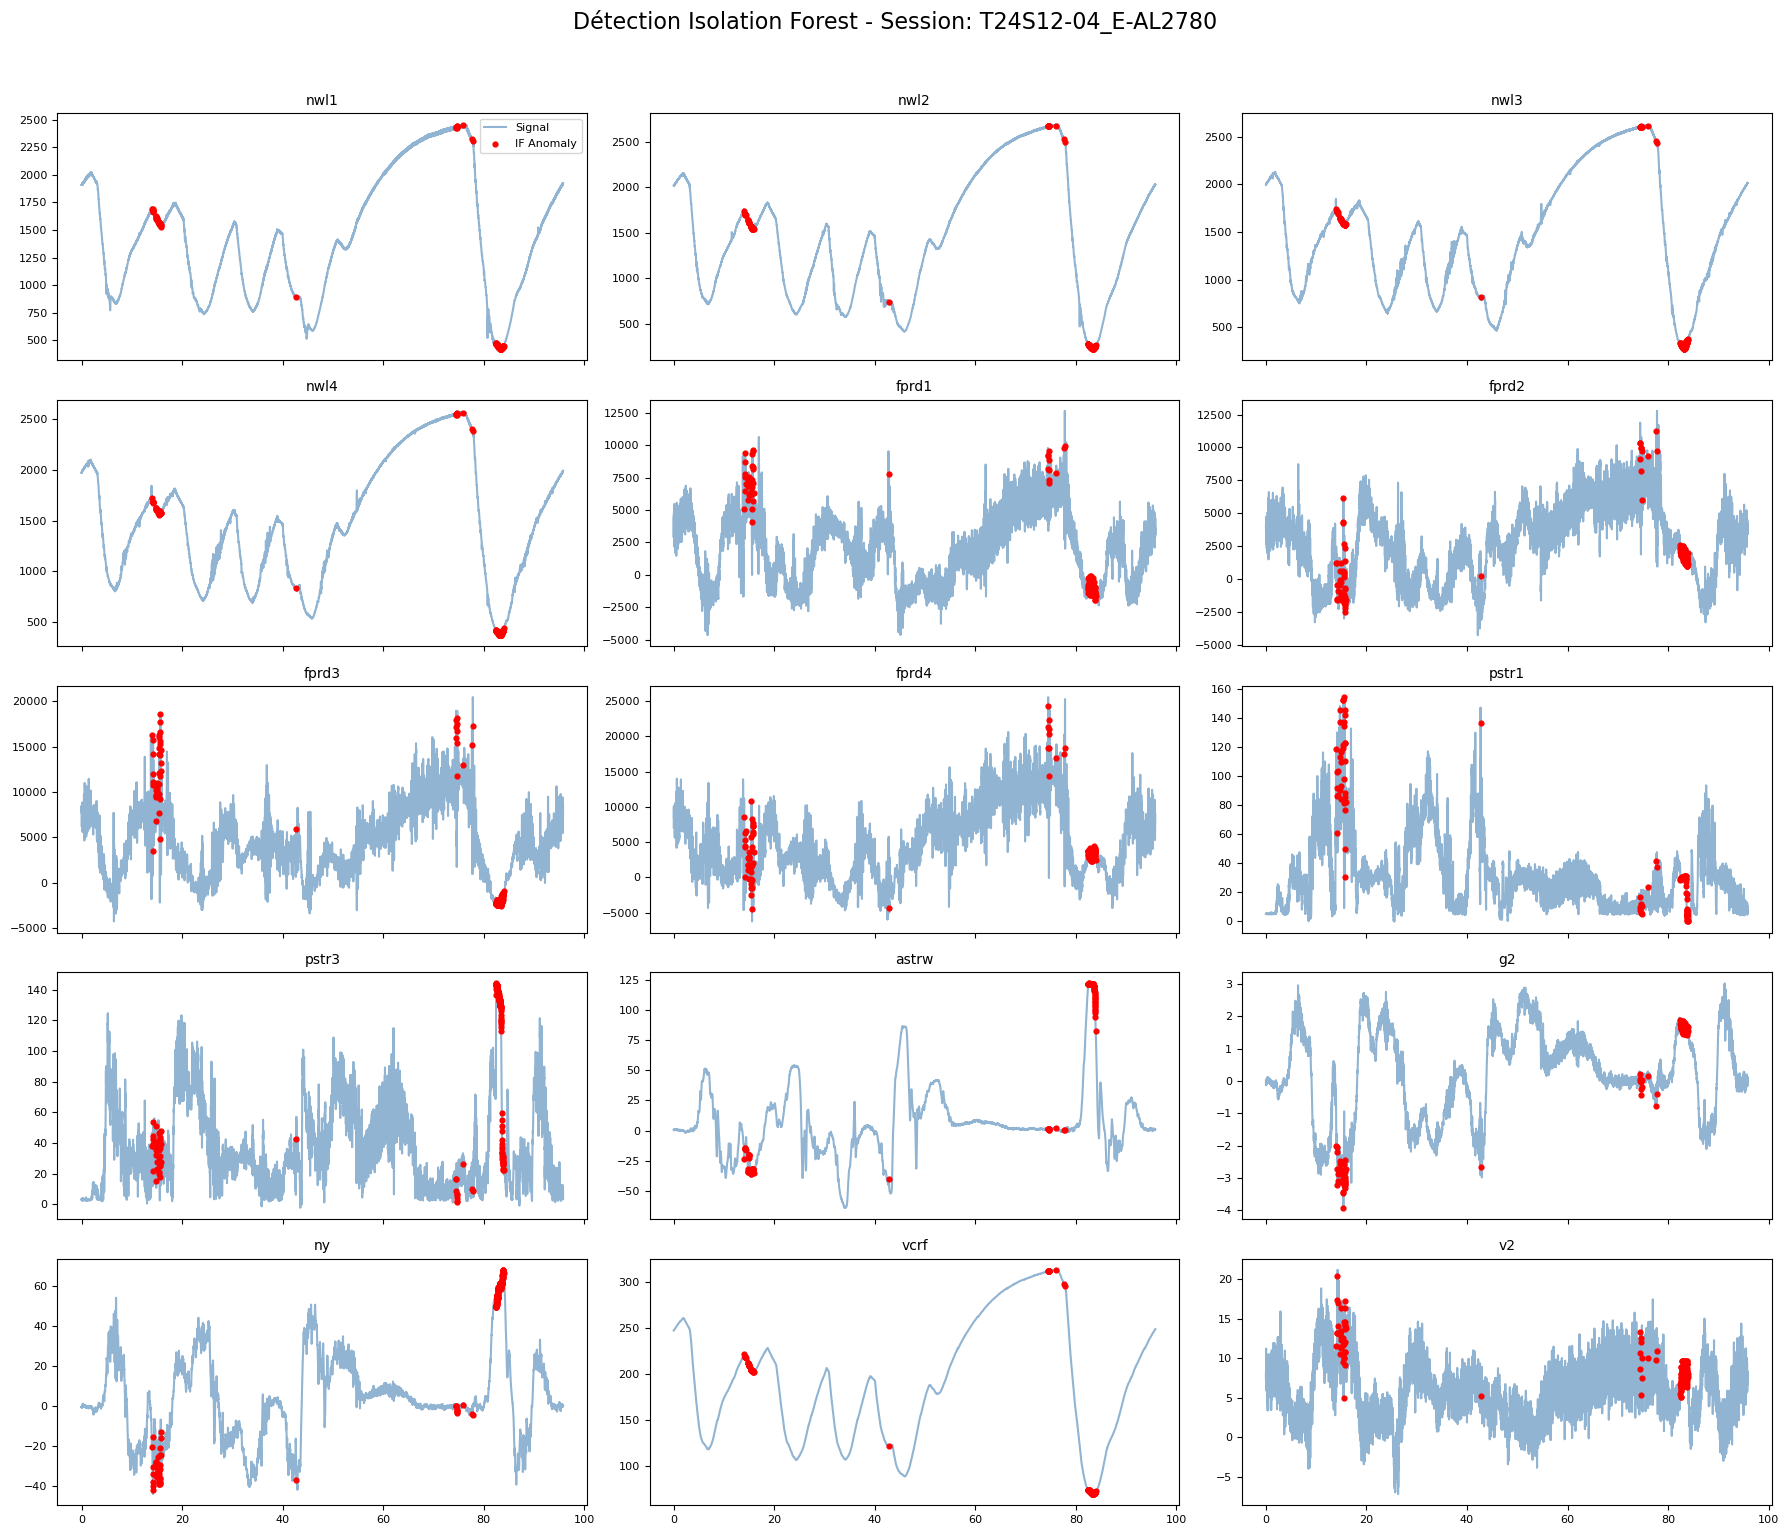

 Session : T24S12-04_E-AL2819
Detection rate : 100.00%


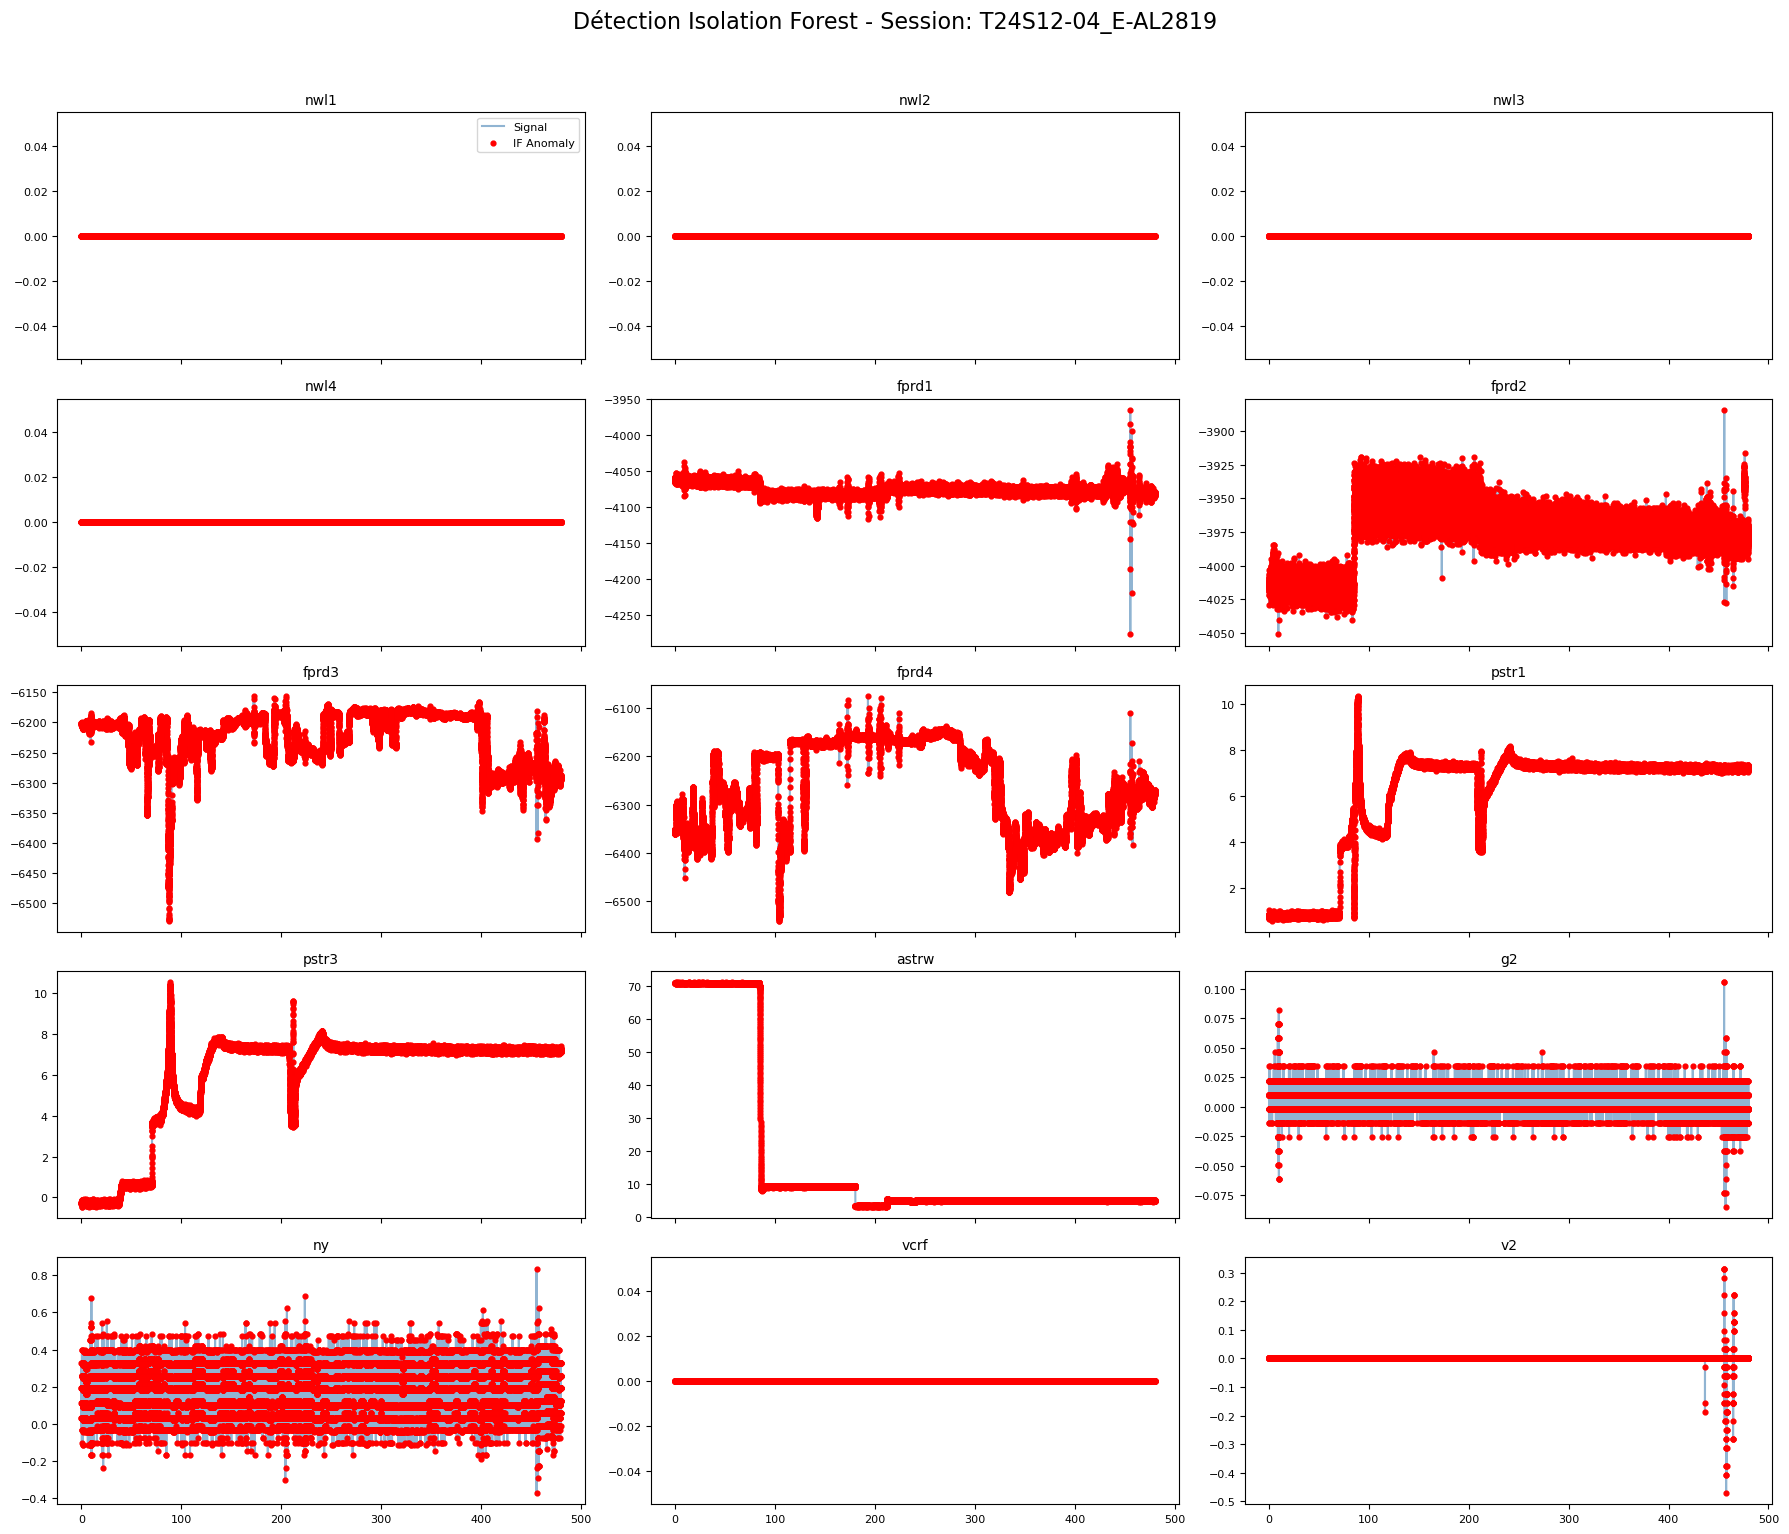

 Session : T24S12-04_E-AL2948
Detection rate : 0.00%


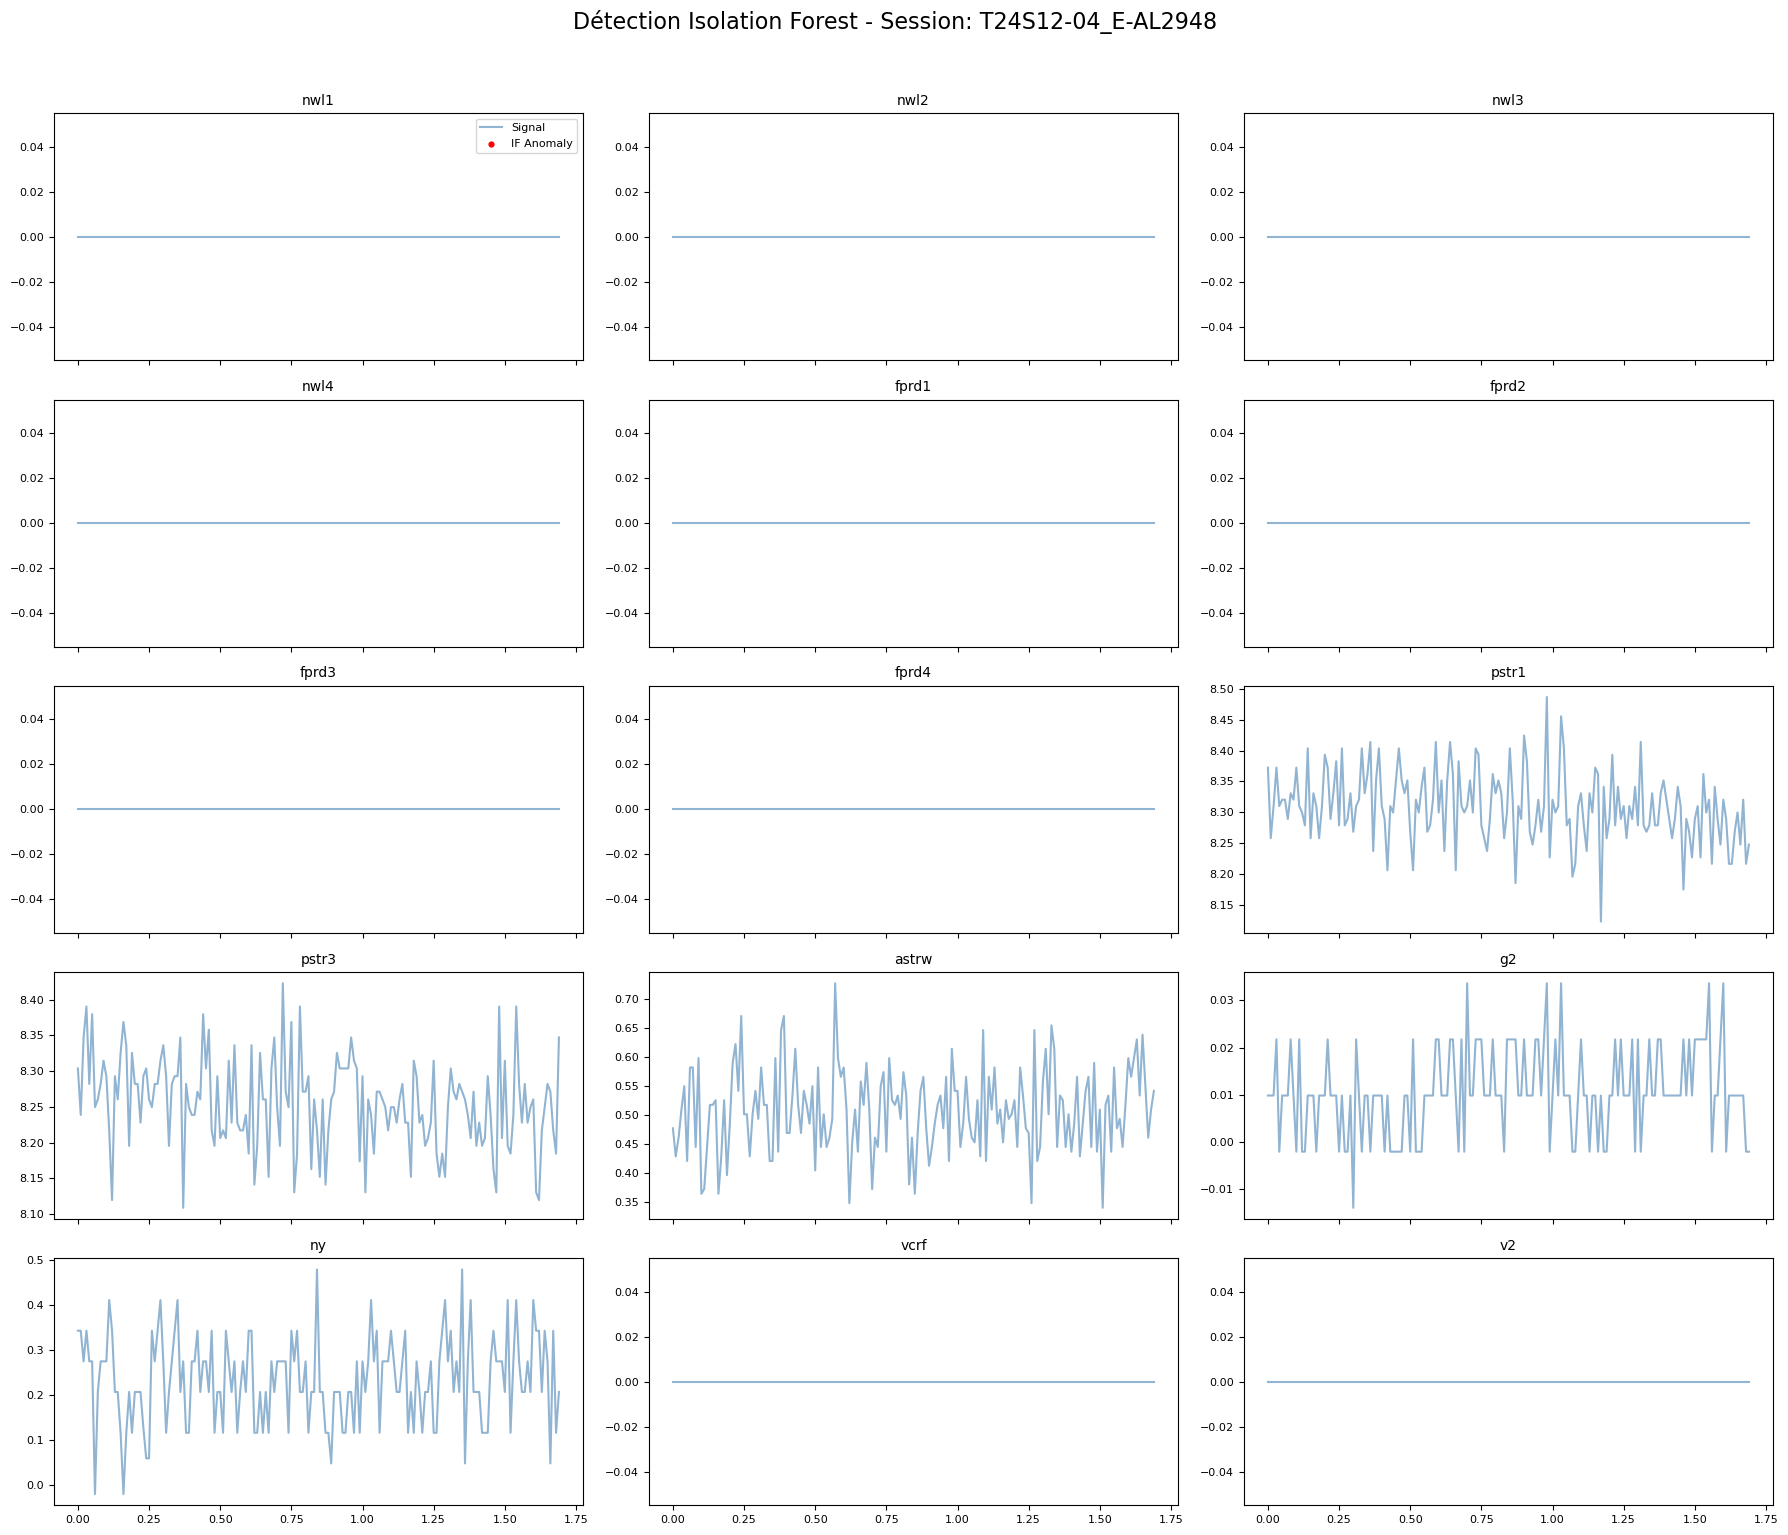

 Session : T24S12-04_E-AL3089
Detection rate : 48.05%


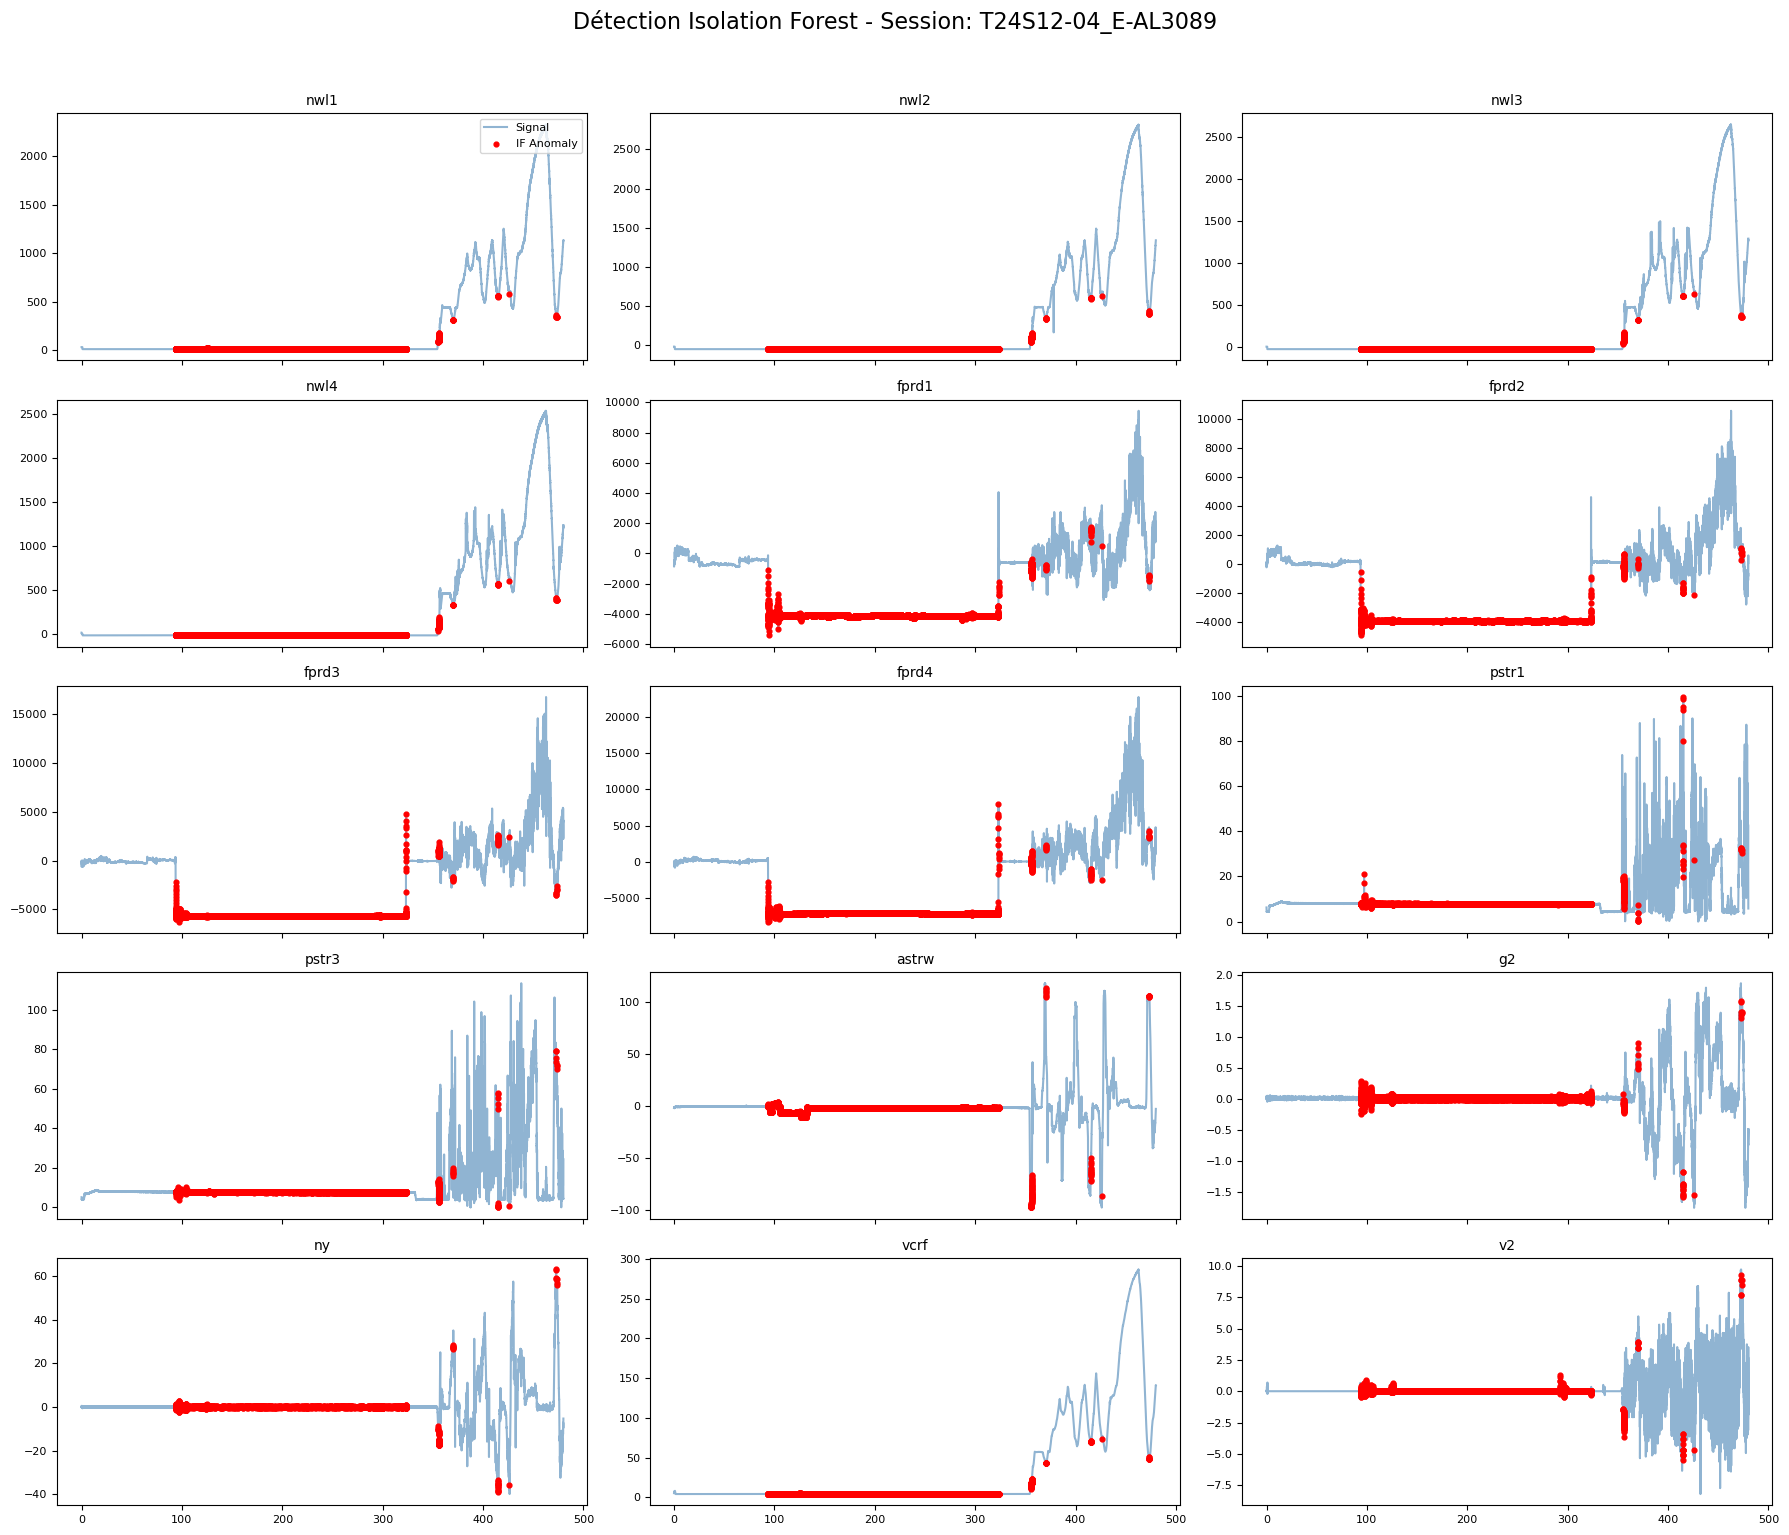

 Session : T24S12-04_E-AL3155
Detection rate : 100.00%


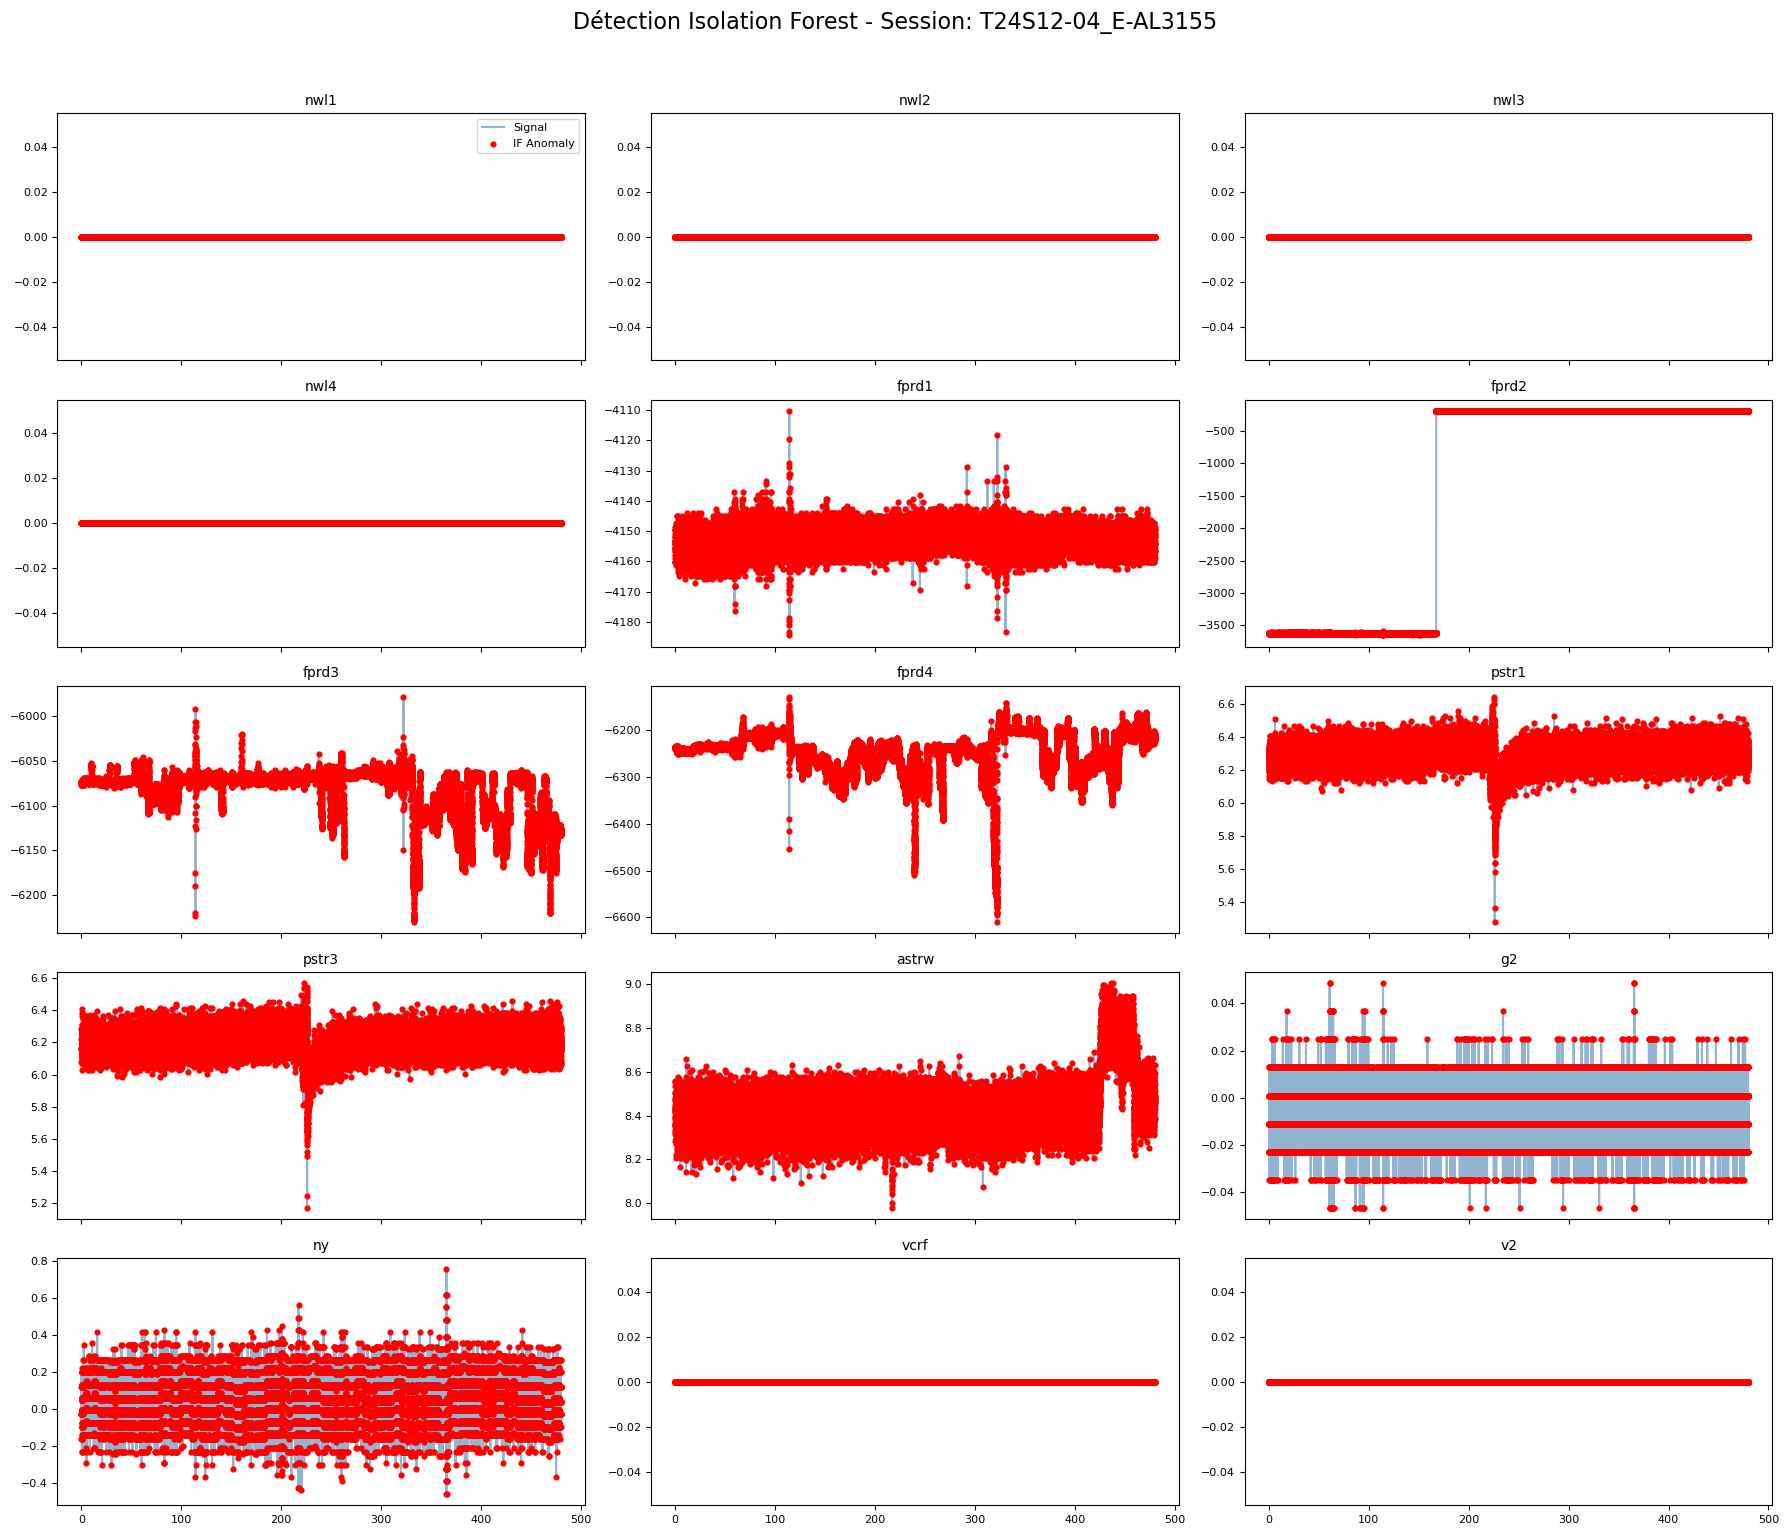

 Session : T24S12-04_E-AL3597
Detection rate : 100.00%


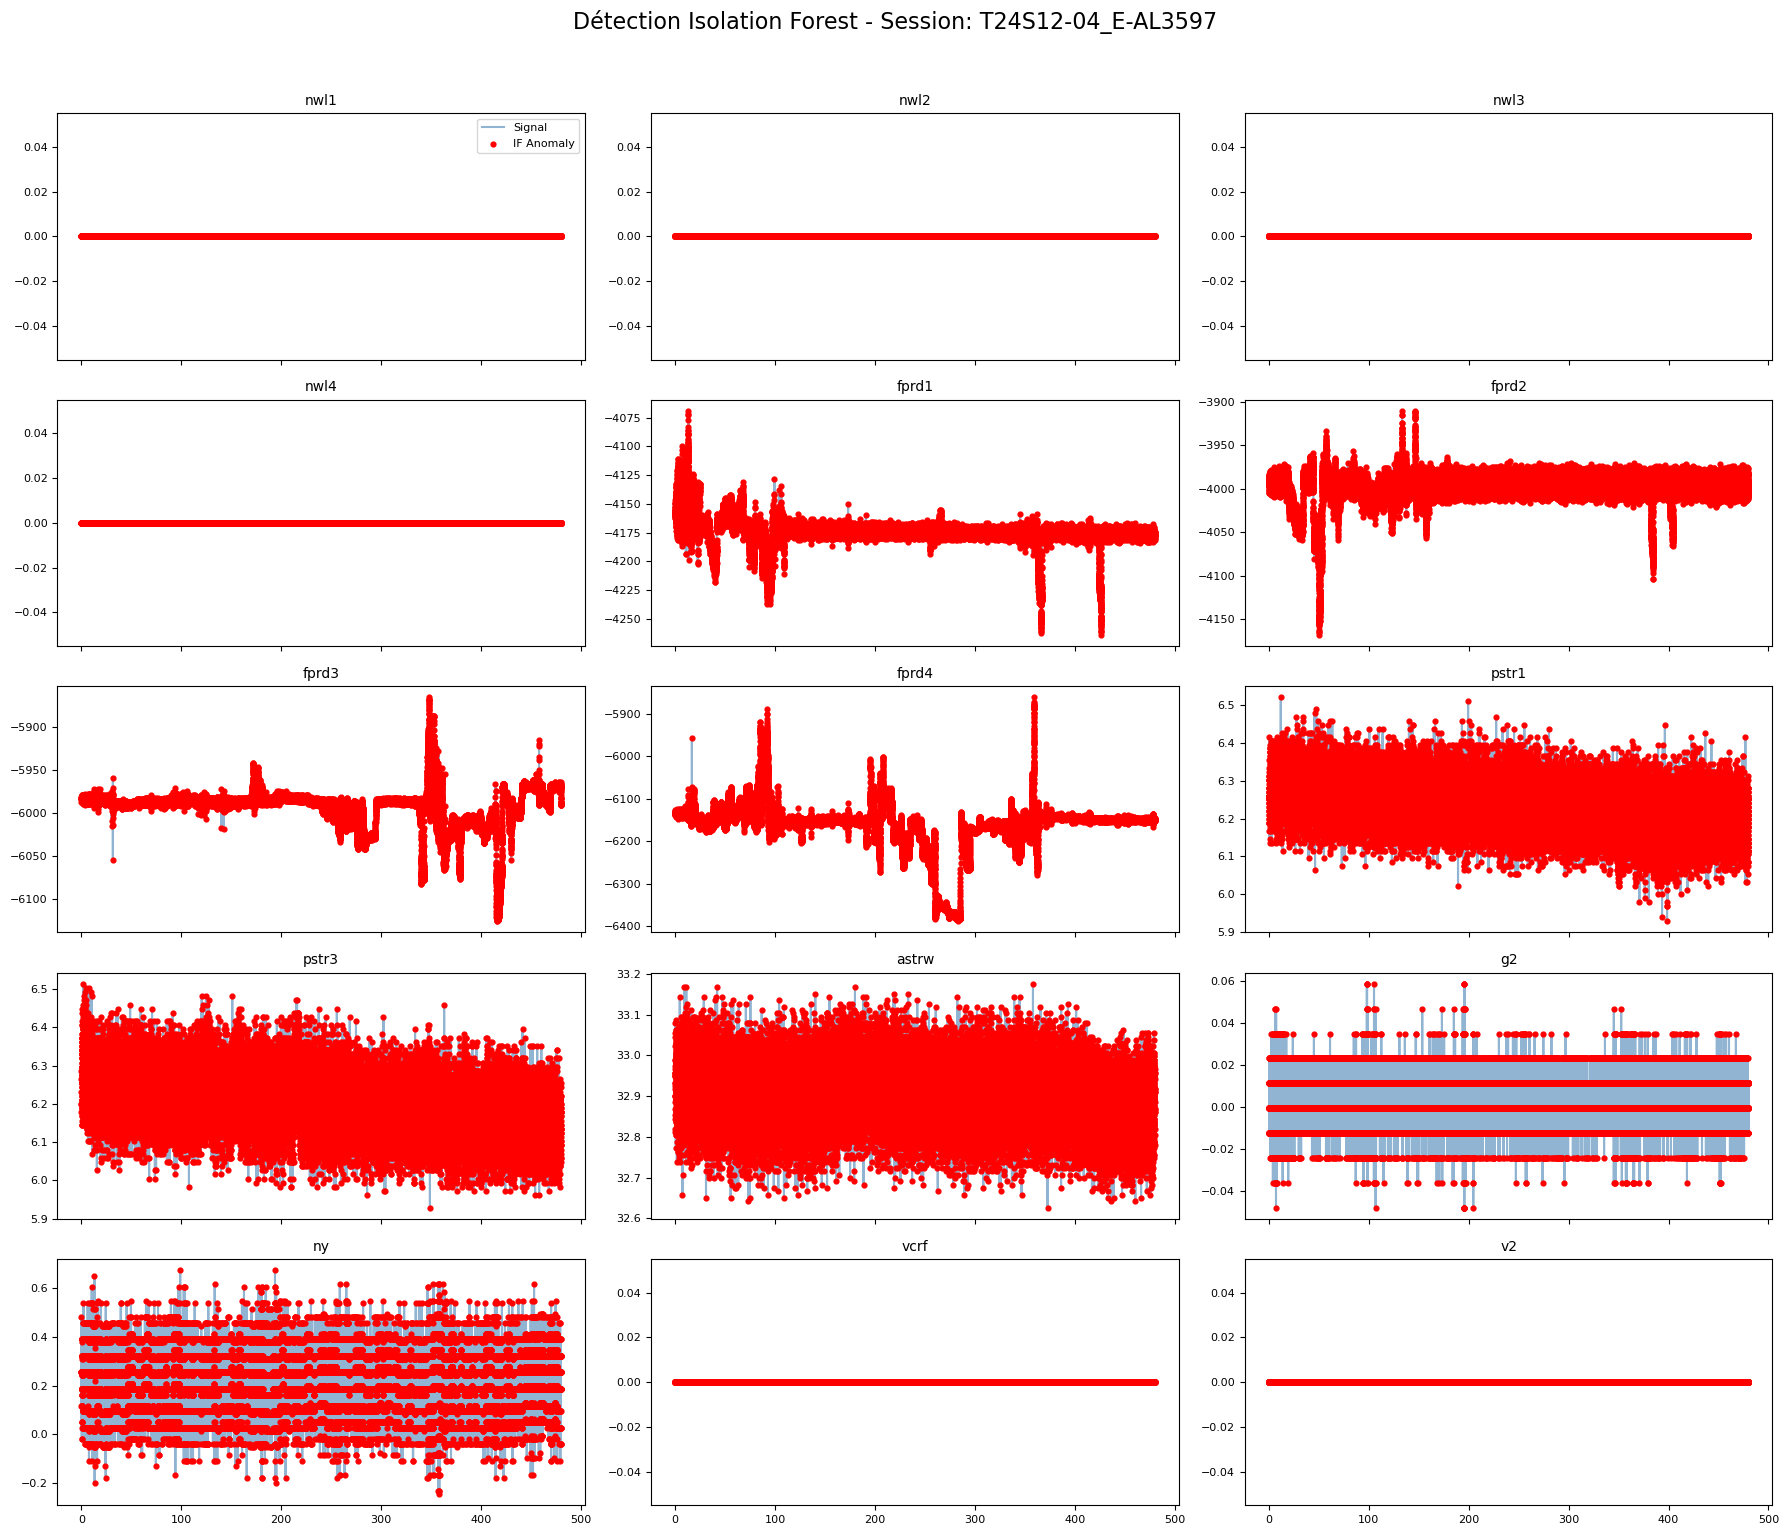

 Session : T24S12-04_E-AL3674
Detection rate : 67.84%


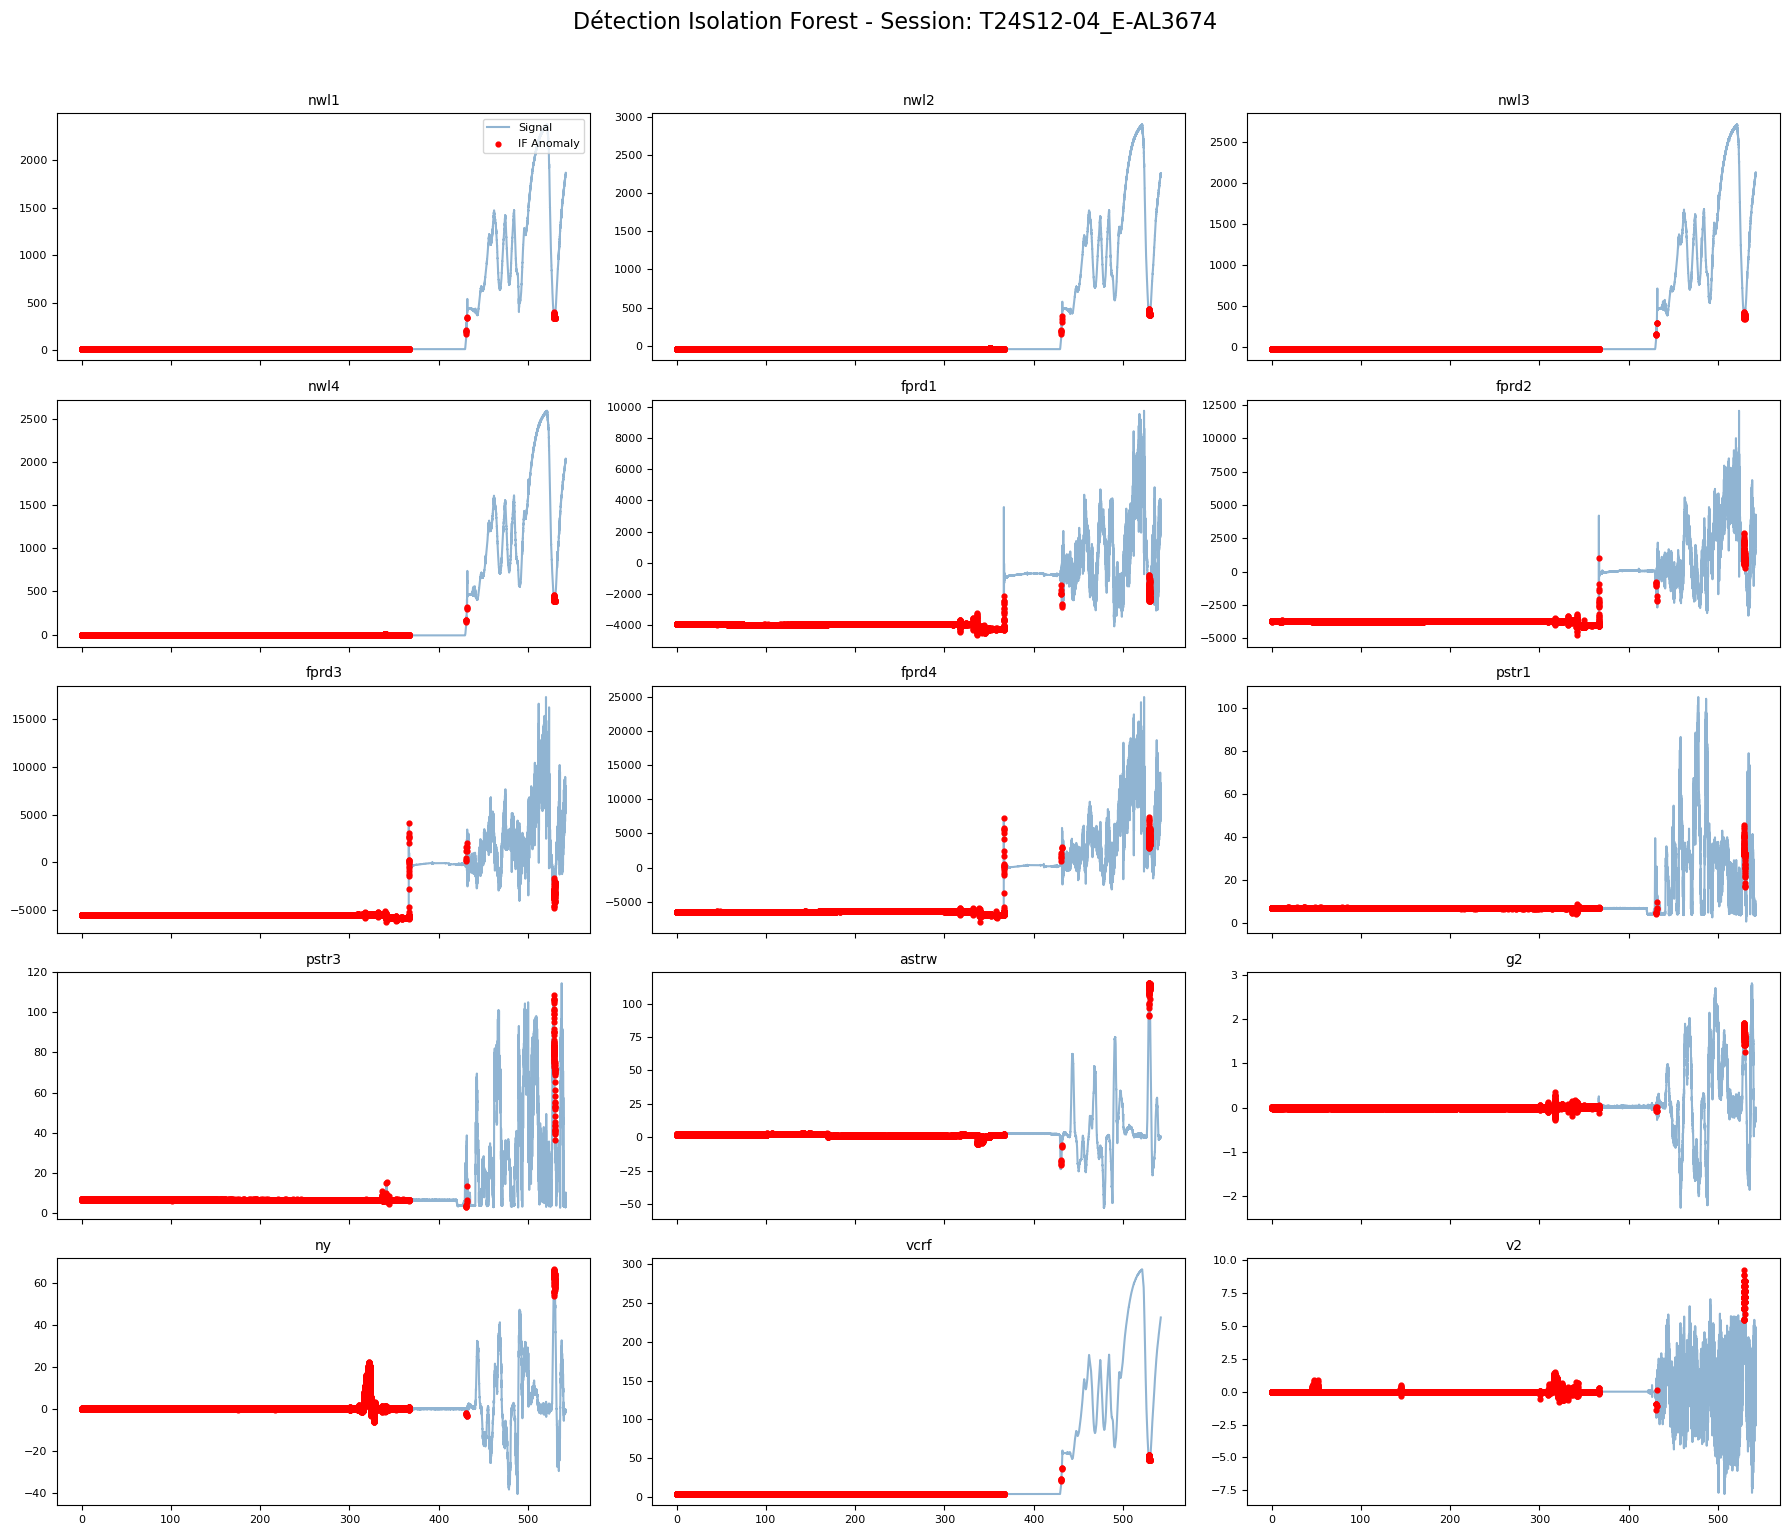

In [43]:
#abnormal sessions from dynamic pca notebook
session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

for name in session_anomaly:
    id_panne_complet = [k for k in data_dict.keys() if name in k][0]

    df_panne = data_dict[id_panne_complet].copy()
    df_panne = preprocessing.clean_dataframe(df_panne)
    results_panne = clf_if.predict_anomalies(df_panne)
    #Print the result
    print(f" Session : {name}")
    print(f"Detection rate : {results_panne['anomaly_detected'].mean() * 100:.2f}%")

    df_plot = results_panne.copy()
    anomaly_mask = df_plot['anomaly_detected'] == 1
    anomaly_times = df_plot.loc[anomaly_mask, 'time_real']

# Select only the sensors 
    cols_to_show = features[:15] 

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 15), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(cols_to_show):
        ax = axes[i]
        
        # Draw the original signal
        ax.plot(df_plot['time_real'], df_plot[col], color='steelblue', alpha=0.6, label='Signal')

        # Overlay the anomaly points in red
        ax.scatter(
            anomaly_times,
            df_plot.loc[anomaly_mask, col],
            color='red',
            s=12,
            label='IF Anomaly',
            zorder=3
        )

        ax.set_title(f"{col}", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)


    plt.suptitle(f"Détection Isolation Forest - Session: {name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
#

The Isolation Forest algorithm yields strong results on sessions labeled as anomalous, successfully identifying significant deviations in sensor magnitudes. However, for a few specific sessions, the detection rate remains notably low.

Visual analysis of the plots suggests these sessions maintain a 'nominal' signal shape but suffer from temporal shifts (time-lag). These deviations are likely not caused by mechanical failures, but by environmental changes (such as rain, road conditions, or different driving styles) that delay the vehicle's response by a few seconds.

Since Isolation Forest is a point-based (point-wise) outlier detector, it treats each timestamp independently. It struggles to capture these 'contextual anomalies' because at any given second, the sensor value remains within a plausible physical range. To effectively distinguish between a true structural fault and a simple environmental shift, a sequence-based model like a GRU-Autoencoder is more robust, as it learns the temporal dependencies and the global dynamics of the system rather than just the distribution of independent points.